# Dataset de Churn de usuários de serviços de telefonia

## Sobre o Conjunto de Dados
### Contexto 
Uma empresa fictícia de telecomunicações que forneceu serviços de telefonia fixa e internet para 7.043 clientes na Califórnia no terceiro trimestre. 

### Fonte 
[Dataset Original Kaggle: Telco_customer_churn.xlsx](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset")

### Objetivo
Criar um modelo de machine learning para prever o churn de cliente no proximo mês.

### Descrição dos Dados 
7.043 observações com 33 variáveis 

**CustomerID**: Um ID único que identifica cada cliente.
 
**Count**: Um valor usado em relatórios e dashboards para somar o número de clientes em um conjunto filtrado.
 
**Country**: O país de residência principal do cliente.
 
**State**: O estado de residência principal do cliente.
 
**City**: A cidade de residência principal do cliente.
 
**Zip Code**: O CEP da residência principal do cliente.
 
**Lat Long**: A combinação de latitude e longitude da residência principal do cliente.
 
**Latitude**: A latitude da residência principal do cliente.
 
**Longitude**: A longitude da residência principal do cliente.
 
**Gender**: O gênero do cliente: Masculino, Feminino.
 
**Senior Citizen**: Indica se o cliente tem 65 anos ou mais: Sim, Não.
 
**Partner**: Indica se o cliente tem um parceiro(a): Sim, Não.
 
**Dependents**: Indica se o cliente mora com dependentes: Sim, Não. Dependentes podem ser filhos, pais, avós, etc.
 
**Tenure Months**: Indica o total de meses que o cliente está com a empresa até o final do trimestre especificado.
 
**Phone Service**: Indica se o cliente assina o serviço de telefone fixo da empresa: Sim, Não.
 
**Multiple Lines**: Indica se o cliente assina múltiplas linhas telefônicas com a empresa: Sim, Não.
 
**Internet Service**: Indica se o cliente assina o serviço de internet da empresa: Não, DSL, Fibra Óptica, Cabo.
 
**Online Security**: Indica se o cliente assina um serviço adicional de segurança online fornecido pela empresa: Sim, Não.
 
**Online Backup**: Indica se o cliente assina um serviço adicional de backup online fornecido pela empresa: Sim, Não.
 
**Device Protection**: Indica se o cliente assina um plano adicional de proteção de dispositivos para seus equipamentos de internet fornecido pela empresa: Sim, Não.
 
**Tech Support**: Indica se o cliente assina um plano adicional de suporte técnico da empresa com tempos de espera reduzidos: Sim, Não.
 
**Streaming TV**: Indica se o cliente utiliza seu serviço de internet para transmitir programação de televisão de um provedor terceiro: Sim, Não. A empresa não cobra taxa adicional por este serviço.
 
**Streaming Movies**: Indica se o cliente utiliza seu serviço de internet para transmitir filmes de um provedor terceiro: Sim, Não. A empresa não cobra taxa adicional por este serviço.
 
**Contract**: Indica o tipo de contrato atual do cliente: Mês a Mês, Um Ano, Dois Anos.
 
**Paperless Billing**: Indica se o cliente optou pela fatura sem papel (digital): Sim, Não.
 
**Payment Method**: Indica como o cliente paga sua fatura: Débito Bancário, Cartão de Crédito, Cheque pelos Correios.
 
**Monthly Charge**: Indica o valor mensal total atual do cliente por todos os seus serviços contratados.
 
**Total Charges**: Indica o total de cobranças do cliente, calculado até o final do trimestre especificado.
 
**Churn Label**: Sim = o cliente deixou a empresa neste trimestre. Não = o cliente permaneceu com a empresa. Diretamente relacionado ao Churn Value.
 
**Churn Value**: 1 = o cliente deixou a empresa neste trimestre. 0 = o cliente permaneceu com a empresa. Diretamente relacionado ao Churn Label.
 
**Churn Score**: Um valor de 0 a 100 calculado pela ferramenta preditiva IBM SPSS Modeler. O modelo incorpora múltiplos fatores conhecidos por causar churn. Quanto maior a pontuação, maior a probabilidade de o cliente cancelar.
 
**CLTV**: Customer Lifetime Value (Valor do Tempo de Vida do Cliente). O CLTV previsto é calculado usando fórmulas corporativas e dados existentes. Quanto maior o valor, mais valioso é o cliente. Clientes de alto valor devem ser monitorados quanto ao risco de churn.
 
**Churn Reason**: O motivo específico do cliente para deixar a empresa. Diretamente relacionado à Churn Category.

### Importação das bibliotecas

In [132]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Célula 3 — módulo interno do projeto
from churn_telecom.config import (
    DATA_INTERIM,
    COLS_ID,
    COLS_CAT,
    COLS_NUM,
    COLS_POS,
    LABEL_COL,
    REPORTS_FIGURES,
    REPORTS_FIGURES_UNIVARIADA,
    REPORTS_FIGURES_MULTIVARIADA,
    REPORT_FIGURES_CORRELACAO,
    TARGET,
    CORES,
    RANDOM_STATE,
)


from churn_telecom.config import get_logger


In [133]:

logger = get_logger("1_vab_eda")
logger.info("Iniciando análise exploratoria de dados | 1_vab_eda")

22:46:20 | INFO | Iniciando análise exploratoria de dados | 1_vab_eda


### Ingestão dos dados
Validação da leitura correta dos dados

In [134]:
df = pd.read_excel("../data/raw/raw_telco_customer_churn.xlsx")
df_eda = df.copy()
logger.info("Copia do dataset original feita com sucesso!")
logger.info("Shape: %s", df.shape)
logger.info("Colunas:\n%s", list(df.columns))

22:46:22 | INFO | Copia do dataset original feita com sucesso!
22:46:22 | INFO | Shape: (7043, 33)
22:46:22 | INFO | Colunas:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [135]:
# Exibir as primeiras linhas do DataFrame
df_eda.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Verficiação dos tipos das features

In [136]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [137]:
# Correção de tipo: Total Charges veio como string
df_eda["Total Charges"] = pd.to_numeric(df_eda["Total Charges"], errors="coerce")
logger.info(
    "Conversão da coluna 'Total Charges' de string (object) para numérica realizada."
)

22:46:22 | INFO | Conversão da coluna 'Total Charges' de string (object) para numérica realizada.


Obs: Foi identificado que a feature "Total Charges" veio como string, sendo na verdade do tipo float, impossibilitando contar os valores faltantes como NaN.



### Tipos de features presentes no Dataset

In [138]:
# Validação de cobertura (executada sobre o df_eda carregado)
all_defined = set(COLS_ID + COLS_NUM + COLS_CAT + COLS_POS + [TARGET, LABEL_COL])
all_columns = set(df_eda.columns)

missing = all_columns - all_defined
orphans = all_defined - all_columns

logger.info("Colunas não categorizadas : %s", missing)
logger.info("Colunas categorizadas ausentes no df: %s", orphans)

assert not missing, f"Categorize as colunas: {missing}"
assert not orphans, f"Colunas inexistentes no df: {orphans}"

logger.info("Colunas numéricas : %d", len(COLS_NUM))
logger.info("Colunas categóricas: %d", len(COLS_CAT))
logger.info("Colunas de ID/Geo  : %d", len(COLS_ID))

22:46:22 | INFO | Colunas não categorizadas : set()
22:46:22 | INFO | Colunas categorizadas ausentes no df: set()
22:46:22 | INFO | Colunas numéricas : 3
22:46:22 | INFO | Colunas categóricas: 16
22:46:22 | INFO | Colunas de ID/Geo  : 9


**Este conjunto de dados contém informações de 7.043 clientes, estruturadas em variáveis que permitem uma análise multidimensional do ciclo de vida do usuário. Sendo categorizados em quatro eixos:**

- Identificação e Localização: Colunas como CustomerID, City, Zip Code e coordenadas geográficas (Lat Long) fornecem o contexto espacial, mas são removidas do treinamento para evitar overfitting e garantir a generalização do modelo.

- Perfil e Fidelidade: Atributos demográficos (Gender, Senior Citizen, Partner, Dependents) e o tempo de permanência (Tenure Months) são cruciais para segmentar o risco.

- Portfólio de Serviços: Inclui o tipo de internet (Fiber Optic, DSL), serviços de segurança (Online Security) e entretenimento (Streaming TV), permitindo identificar quais produtos retêm ou afastam o cliente.

- Financeiro e Target: Variáveis como Monthly Charges, Total Charges, Contract e Payment Method representam a elasticidade de preço. O alvo principal é o Churn Value (0 ou 1), enquanto métricas como CLTV e Churn Score servem para a análise de viabilidade econômica e trade-off de custos do projeto.

### Observações sobre as categorias das features
- Churn Score e CLTV saem de cols_num. Ambas parecem numéricas inofensivas, mas são geradas por um modelo IBM que já sabe quem cancelou. Incluí-las seria vazar o futuro para o modelo — ele aprenderia a copiar o score em vez de aprender padrões reais de comportamento.
- Churn Reason sai de cols_cat. Só existe para clientes que já saíram, então teria 73% de nulos estruturais no treino — e seria nulo 100% das vezes em produção, onde você precisa prever antes do cancelamento.
target vs label_col separados explicitamente. 
- Churn Value (0/1) vai para o modelo; 
- Churn Label (Yes/No) fica apenas para inspeção humana. Essa distinção evita que alguém acidentalmente encode a string como feature categórica nos próximos notebooks.

### Validação de nulos e/ou duplicados

,Coluna,Qtd_Nulos,Pct_Nulos
Churn Reason,Churn Reason,5174,73.46
Total Charges,Total Charges,11,0.16


22:46:22 | INFO | Nulos | Churn Reason | count=5174 | 73.46%
22:46:22 | INFO | Nulos | Total Charges | count=11 | 0.16%


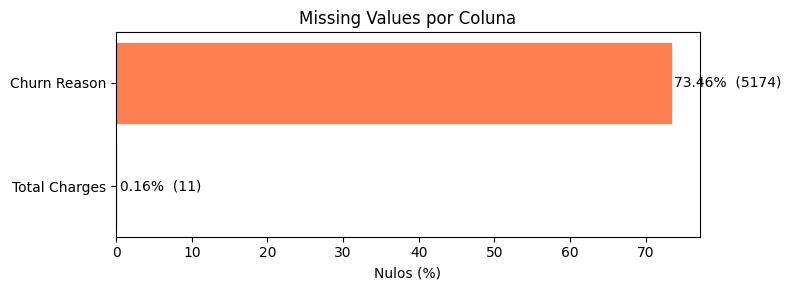

22:46:22 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\missing_values.png


In [139]:
# ── Análise de valores ausentes ───────────────────────────────────────────────
# Constrói DataFrame com contagem e percentual de nulos por coluna
missing_values = pd.DataFrame(
    {
        "Coluna": df_eda.columns,
        "Qtd_Nulos": df_eda.isnull().sum(),
        "Pct_Nulos": (df_eda.isnull().sum() / len(df_eda) * 100).round(2),
    }
)

# Filtra apenas colunas com nulos e ordena do mais crítico para o menos
missing_values = missing_values[missing_values["Qtd_Nulos"] > 0].sort_values(
    by="Pct_Nulos", ascending=False
)
display(missing_values)

if len(missing_values) > 0:
    # Altura dinâmica: evita gráfico achatado para muitas colunas
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_values) * 1.2)))

    ax.barh(
        missing_values["Coluna"],
        missing_values["Pct_Nulos"],
        color=CORES["destaque"],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Nulos (%)")
    ax.set_title("Missing Values por Coluna")
    ax.invert_yaxis()  # coluna mais crítica no topo

    for i, (_, row) in enumerate(missing_values.iterrows()):
        # Anotação inline: exibe % e contagem absoluta na barra
        ax.text(
            row["Pct_Nulos"] + 0.3,
            i,
            f"{row['Pct_Nulos']}%  ({int(row['Qtd_Nulos'])})",
            va="center",
            fontsize=10,
        )
        logger.info(
            "Nulos | %s | count=%d | %.2f%%",
            row["Coluna"],
            int(row["Qtd_Nulos"]),
            row["Pct_Nulos"],
        )

    plt.tight_layout()
    output_path = REPORTS_FIGURES / "missing_values.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()
    logger.info("Artefato salvo: %s", output_path)

else:
    logger.info("Nenhum missing value detectado no dataset.")

# Contexto de negócio dos nulos encontrados:
# - Churn Reason : 73.46% nulos — esperado, só clientes que cancelaram têm motivo registrado
# - Total Charges:  0.16% nulos — clientes com Tenure = 0 (recém-chegados, sem cobrança ainda)

In [140]:
# Valores duplicados
n_dup = df_eda.duplicated().sum()
logger.info("Linhas duplicadas encontradas: %d", n_dup)  # Esperado: 0

22:46:22 | INFO | Linhas duplicadas encontradas: 0


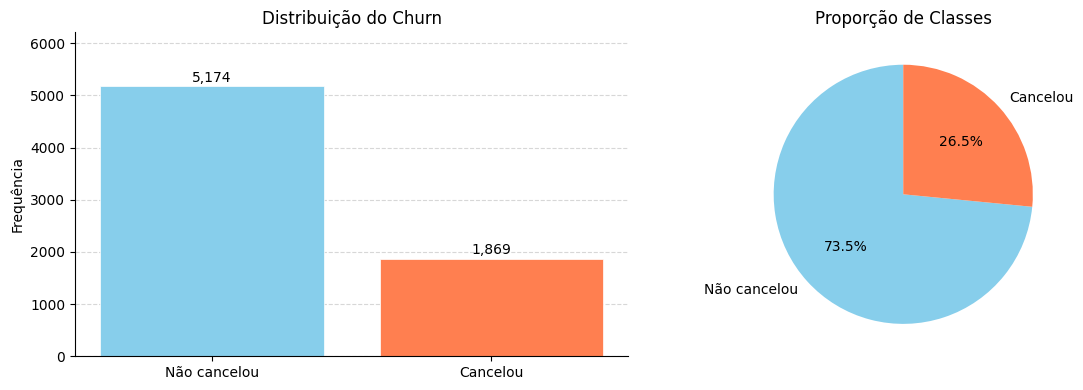

22:46:22 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\churn_distribution.png
22:46:22 | INFO | Target | Não cancelou (=0) | count=5174 | 73.46%
22:46:22 | INFO | Target | Cancelou (=1) | count=1869 | 26.54%
22:46:22 | WARNING | Dataset desbalanceado (ratio=0.36) — usar class_weight='balanced' ou SMOTE na modelagem.


In [141]:
# ── Distribuição da variável target ───────────────────────────────────────────
target_counts = df_eda[TARGET].value_counts()
target_pct = df_eda[TARGET].value_counts(normalize=True).mul(100).round(2)

# Labels legíveis para exibição nos gráficos
labels = {0: "Não cancelou", 1: "Cancelou"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Gráfico de barras — frequência absoluta ───────────────────────────────────
bar_labels = [labels[i] for i in target_counts.index]
bars = axes[0].bar(
    bar_labels,
    target_counts.values,
    color=[CORES["primaria"], CORES["destaque"]],
    edgecolor="white",
    linewidth=0.5,
    zorder=2,  # barras na frente do grid
)
# Contagem anotada no topo de cada barra
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição do Churn")
axes[0].set_ylim(0, target_counts.max() * 1.2)  # espaço para anotações
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)  # grid atrás das barras
axes[0].set_axisbelow(True)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Gráfico de pizza — proporção de classes ───────────────────────────────────
axes[1].pie(
    target_counts.values,
    labels=[labels[i] for i in target_counts.index],
    autopct="%1.1f%%",
    colors=[CORES["primaria"], CORES["destaque"]],
    startangle=90,
)
axes[1].set_title("Proporção de Classes")

plt.tight_layout()
output_path = REPORTS_FIGURES / "churn_distribution.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close()
logger.info("Artefato salvo: %s", output_path)

# Log por classe
for idx in target_counts.index:
    logger.info(
        "Target | %s (=%d) | count=%d | %.2f%%",
        labels[idx],
        idx,
        target_counts[idx],
        target_pct[idx],
    )

# Avalia desbalanceamento via ratio min/max
ratio = target_counts.min() / target_counts.max()
if ratio < 0.5:
    logger.warning(
        "Dataset desbalanceado (ratio=%.2f) — usar class_weight='balanced' ou SMOTE na modelagem.",
        ratio,
    )
else:
    logger.info("Dataset balanceado (ratio=%.2f).", ratio)

## Análise Inicial do Dataset — Data Understanding

### Dimensionalidade e Estrutura

O dataset contém 7.043 clientes e 33 variáveis brutas, reduzidas para 20 após a remoção de
identificadores, colunas geográficas e variáveis de leakage. A distribuição por tipo ficou:
3 numéricas (`Tenure Months`, `Monthly Charges`, `Total Charges`), 16 categóricas e 9 de
ID/Geo descartadas.

---

### Qualidade dos Dados

Dois problemas identificados:

`Total Charges` chegou como `object` no raw — convertida para `float64` via
`pd.to_numeric(errors='coerce')`, gerando 11 nulos (0.16%) correspondentes a clientes com
`Tenure Months = 0`, ou seja, recém-chegados sem nenhuma cobrança acumulada. Estratégia:
imputar com `0` no notebook `1.01-cleaning`, pois a ausência reflete um estado real do
negócio, não um dado faltante.

`Churn Reason` tem 73.46% de nulos (5.174 registros) — estruturalmente esperado, pois só
clientes que cancelaram têm motivo registrado. Essa coluna está isolada em `cols_pos` e não
entrará no modelo.

Zero duplicatas confirmado.

---

### Desbalanceamento de Classes

| Classe            | Contagem |    %  |
|-------------------|----------|-------|
| Não cancelou (0)  |   5.174  | 73.46% |
| Cancelou (1)      |   1.869  | 26.54% |
| **Ratio**         | **0.36** | —      |

O ratio de 0.36 confirma desbalanceamento moderado. Com ratio < 0.5 duas estratégias serão
avaliadas na modelagem:

- `class_weight='balanced'` nos modelos sklearn (Regressão Logística, baseline)
- `pos_weight` no `BCEWithLogitsLoss` do PyTorch (MLP)

SMOTE será avaliado como alternativa se as métricas de Recall ficarem insatisfatórias.

---

### Implicação Direta no Negócio

O desbalanceamento reflete a realidade operacional — a maioria dos clientes não cancela.
Isso torna o Recall da classe positiva (Cancelou=1) a métrica mais crítica:

- **Falso Negativo**: cliente que vai cancelar e não foi identificado → receita perdida
permanentemente.
- **Falso Positivo**: campanha de retenção desnecessária → custo controlável.

Essa assimetria de custos será formalizada no ML Canvas na próxima etapa.

---

### Próximos Passos

O dataset está íntegro e pronto para avançar. O `telco_typed.parquet` com shape `(7043, 20)`
é a entrada do `0.02-eda-univariate`, que analisará as distribuições individuais das
3 numéricas e 16 categóricas sem segmentação por target.

### Exportar os dados com tipos corrigidos e com as features exatas a serem analisadas:

In [142]:
# Colunas de identificação e pos avaliação a descartar antes de salvar
cols_drop = COLS_ID + COLS_POS + [LABEL_COL]

df_interim = df_eda.drop(columns=cols_drop).copy()

# Dataset corrigido e tipado — pronto para as próximas etapas do pipeline
df_interim.to_parquet("../data/interim/telco_typed.parquet", index=False)
logger.info(
    "Dataset salvo: data/interim/telco_typed.parquet — shape: %s", df_interim.shape
)
logger.info(
    "Colunas deletadas: %s", cols_drop
)

22:46:22 | INFO | Dataset salvo: data/interim/telco_typed.parquet — shape: (7043, 20)
22:46:22 | INFO | Colunas deletadas: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']


In [143]:
# Dataset após remover  colunas de ID e pós-avaliação
df = pd.read_parquet(DATA_INTERIM / "telco_typed.parquet")
logger.info("Dataset carregado. Shape: %s", df.shape)
df.head(5)

22:46:22 | INFO | Dataset carregado. Shape: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


22:46:22 | INFO | Análise univariada iniciada para 3 variáveis numéricas.


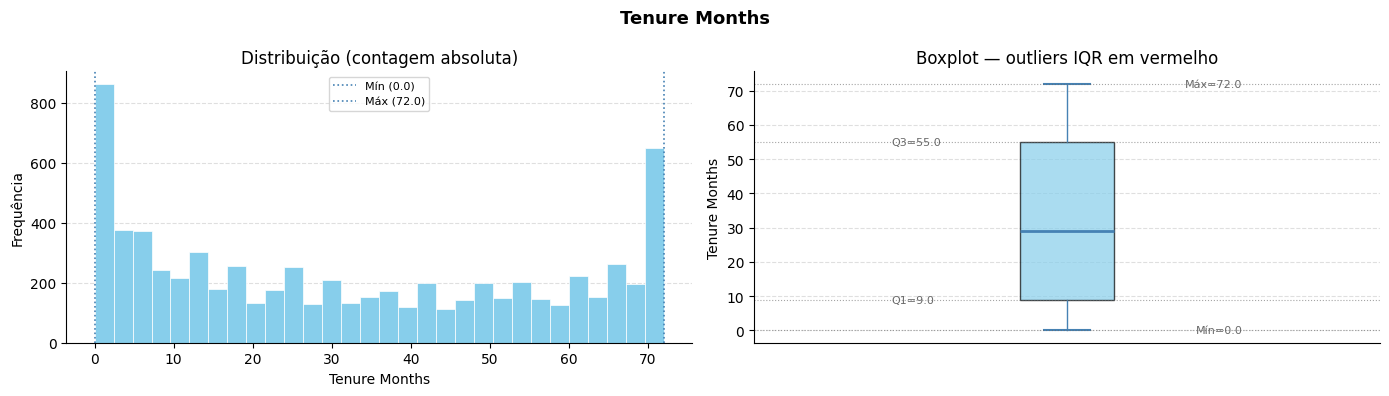

22:46:23 | INFO | Tenure Months | n=7043 | média=32.37 | mediana=29.00 | std=24.56 | min=0.00 | max=72.00 | q1=9.00 | q3=55.00 | iqr=46.00 | lim_inf=-60.00 | lim_sup=124.00 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
22:46:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_num_tenure_months.png


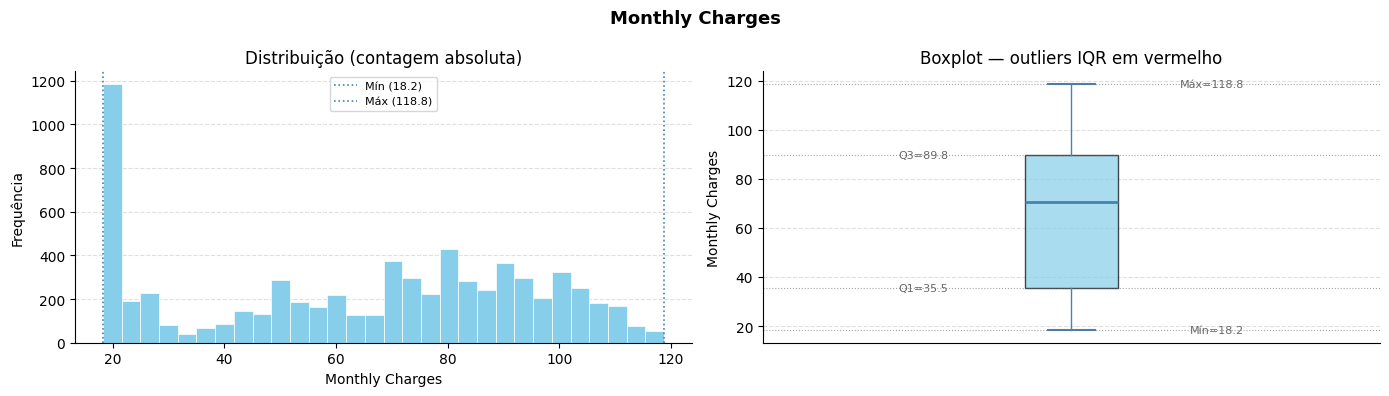

22:46:23 | INFO | Monthly Charges | n=7043 | média=64.76 | mediana=70.35 | std=30.09 | min=18.25 | max=118.75 | q1=35.50 | q3=89.85 | iqr=54.35 | lim_inf=-46.02 | lim_sup=171.38 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
22:46:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_num_monthly_charges.png


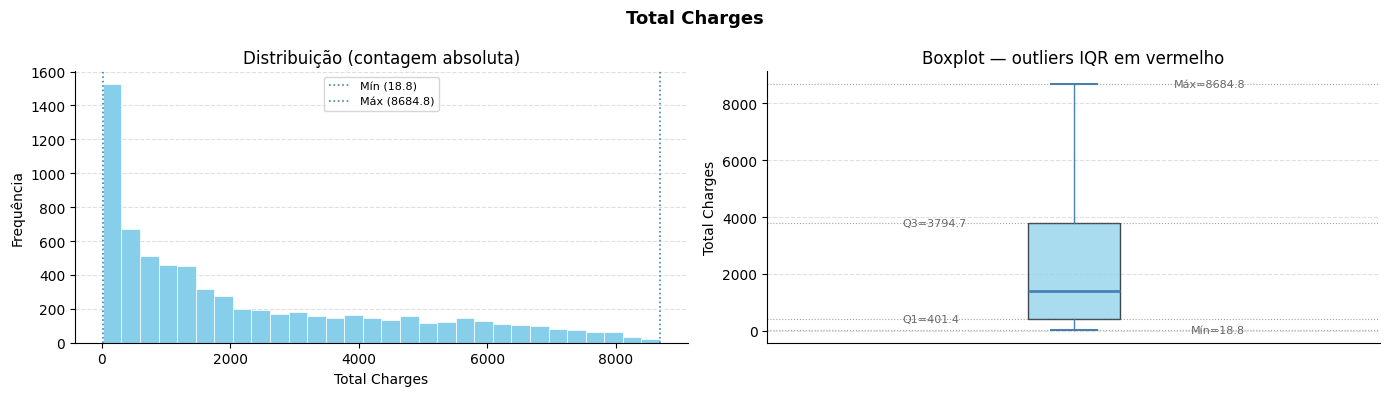

22:46:23 | INFO | Total Charges | n=7032 | média=2283.30 | mediana=1397.47 | std=2266.77 | min=18.80 | max=8684.80 | q1=401.45 | q3=3794.74 | iqr=3393.29 | lim_inf=-4688.48 | lim_sup=8884.67 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
22:46:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_num_total_charges.png
22:46:23 | INFO | Análise univariada finalizada para 3 variáveis numéricas.


In [144]:
logger.info("Análise univariada iniciada para %d variáveis numéricas.", len(COLS_NUM))
# ── EDA Univariada — Variáveis Numéricas ──────────────────────────────────────


for col in COLS_NUM:
    series = df[col].dropna()

    # ── Estatísticas descritivas ──────────────────────────────────────────────
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    val_min = series.min()
    val_max = series.max()

    # Outliers via IQR
    mask_iqr = (series < lim_inf) | (series > lim_sup)
    n_out_iqr = mask_iqr.sum()
    pct_out_iqr = n_out_iqr / len(series) * 100

    # Outliers via Z-score (|z| > 3)
    z_scores = np.abs(stats.zscore(series))
    mask_z = z_scores > 3
    n_out_z = mask_z.sum()
    pct_out_z = n_out_z / len(series) * 100

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(col, fontsize=13, fontweight="bold")

    # ── Histograma — contagem absoluta, apenas mín e máx ─────────────────────
    axes[0].hist(
        series,
        bins=30,
        color=CORES["primaria"],
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )
    axes[0].axvline(
        val_min,
        color=CORES["secundaria"],
        linestyle=":",
        linewidth=1.2,
        label=f"Mín ({val_min:.1f})",
    )
    axes[0].axvline(
        val_max,
        color=CORES["secundaria"],
        linestyle=":",
        linewidth=1.2,
        label=f"Máx ({val_max:.1f})",
    )
    axes[0].set_title("Distribuição (contagem absoluta)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequência")
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    axes[0].set_axisbelow(True)
    axes[0].spines[["top", "right"]].set_visible(False)
    axes[0].legend(fontsize=8)

    # ── Boxplot univariado — limites IQR, Q1, Q3, mín, máx ───────────────────
    axes[1].boxplot(
        series,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=CORES["primaria"], alpha=0.7),
        medianprops=dict(color=CORES["secundaria"], linewidth=2),
        whiskerprops=dict(color=CORES["secundaria"], linewidth=1),
        capprops=dict(color=CORES["secundaria"], linewidth=1.5),
        flierprops=dict(marker="o", color=CORES["alerta"], alpha=0.5, markersize=4),
    )
    # Anotações para Q1, Q3, mín e máx
    for val, label, side in [
        (q1, f"Q1={q1:.1f}", "left"),
        (q3, f"Q3={q3:.1f}", "left"),
        (val_min, f"Mín={val_min:.1f}", "right"),
        (val_max, f"Máx={val_max:.1f}", "right"),
    ]:
        axes[1].axhline(
            val, color=CORES["neutro"], linestyle=":", linewidth=0.8, alpha=0.6
        )
        x_pos = 0.72 if side == "left" else 1.28
        axes[1].text(
            x_pos,
            val,
            label,
            va="center",
            fontsize=8,
            color=CORES["neutro"],
            ha="left" if side == "left" else "right",
        )
    axes[1].set_title("Boxplot — outliers IQR em vermelho")
    axes[1].set_ylabel(col)
    axes[1].set_xticks([])
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    axes[1].set_axisbelow(True)
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_UNIVARIADA / f"univariate_num_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado ───────────────────────────────────────────────────────
    logger.info(
        "%s | n=%d | média=%.2f | mediana=%.2f | std=%.2f | "
        "min=%.2f | max=%.2f | "
        "q1=%.2f | q3=%.2f | iqr=%.2f | "
        "lim_inf=%.2f | lim_sup=%.2f | "
        "outliers_iqr=%d (%.2f%%) | "
        "outliers_zscore=%d (%.2f%%)",
        col,
        len(series),
        series.mean(),
        series.median(),
        series.std(),
        val_min,
        val_max,
        q1,
        q3,
        iqr,
        lim_inf,
        lim_sup,
        n_out_iqr,
        pct_out_iqr,
        n_out_z,
        pct_out_z,
    )
    logger.info("Artefato salvo: %s", output_path)
logger.info("Análise univariada finalizada para %d variáveis numéricas.", len(COLS_NUM))

22:46:23 | INFO | Análise univariada iniciada para 16 variáveis categóricas.


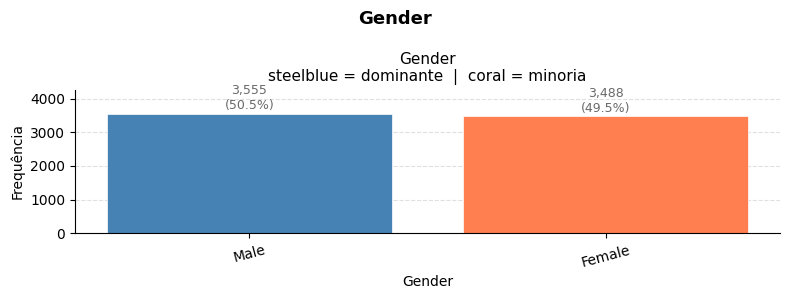

22:46:23 | INFO | Gender | n=7043 | nulos=0 | categorias=2 | dominante='Male' (50.5%) | minoria='Female' (49.5%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:23 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_gender.png


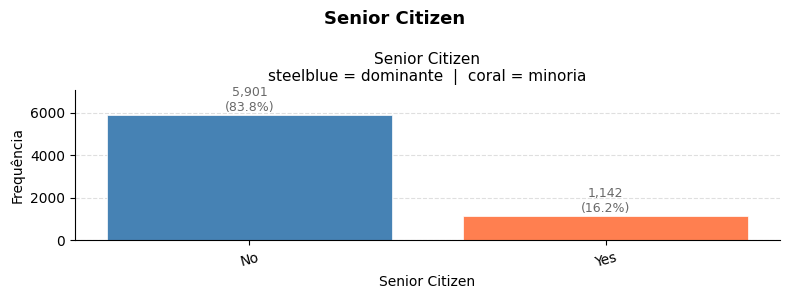

22:46:24 | INFO | Senior Citizen | n=7043 | nulos=0 | categorias=2 | dominante='No' (83.8%) | minoria='Yes' (16.2%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=True
22:46:24 | WARNING | Senior Citizen | alta concentração: 'No' ocupa 83.8% — avaliar poder preditivo
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_senior_citizen.png


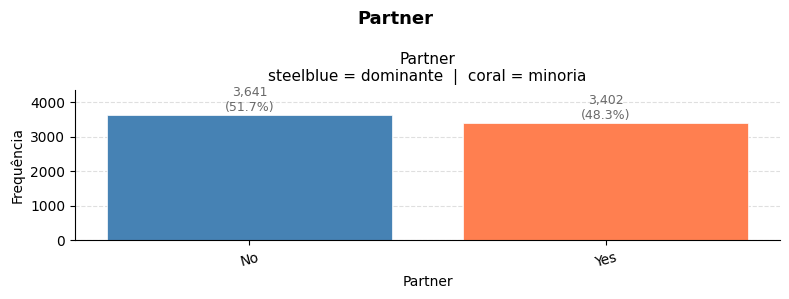

22:46:24 | INFO | Partner | n=7043 | nulos=0 | categorias=2 | dominante='No' (51.7%) | minoria='Yes' (48.3%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_partner.png


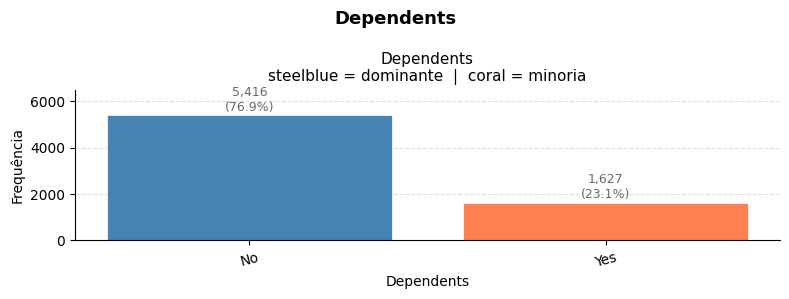

22:46:24 | INFO | Dependents | n=7043 | nulos=0 | categorias=2 | dominante='No' (76.9%) | minoria='Yes' (23.1%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_dependents.png


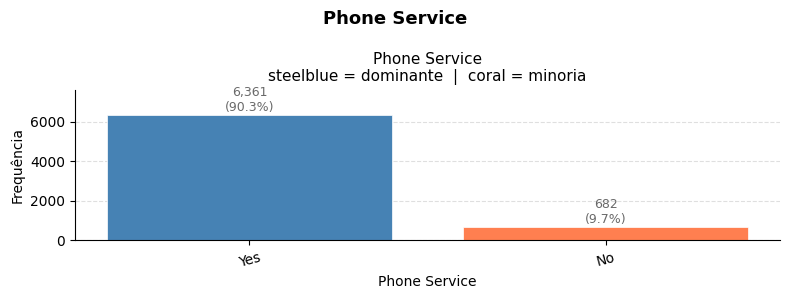

22:46:24 | INFO | Phone Service | n=7043 | nulos=0 | categorias=2 | dominante='Yes' (90.3%) | minoria='No' (9.7%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=True
22:46:24 | WARNING | Phone Service | alta concentração: 'Yes' ocupa 90.3% — avaliar poder preditivo
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_phone_service.png


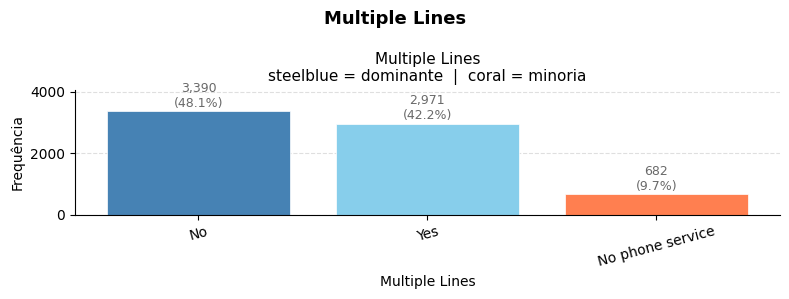

22:46:24 | INFO | Multiple Lines | n=7043 | nulos=0 | categorias=3 | dominante='No' (48.1%) | minoria='No phone service' (9.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_multiple_lines.png


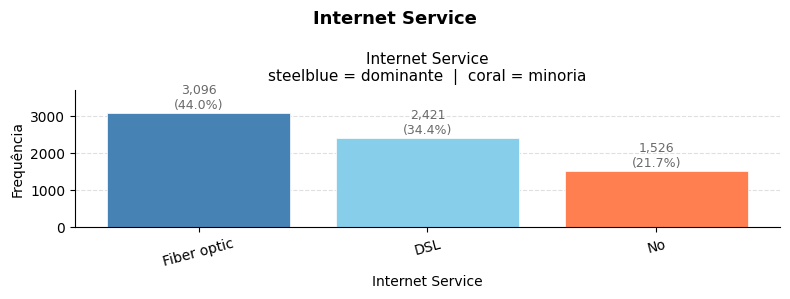

22:46:24 | INFO | Internet Service | n=7043 | nulos=0 | categorias=3 | dominante='Fiber optic' (44.0%) | minoria='No' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_internet_service.png


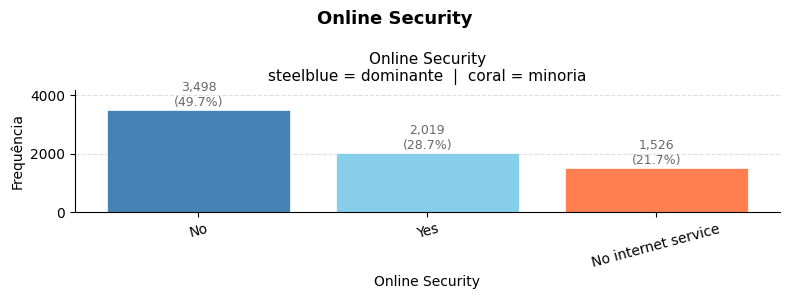

22:46:24 | INFO | Online Security | n=7043 | nulos=0 | categorias=3 | dominante='No' (49.7%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_online_security.png


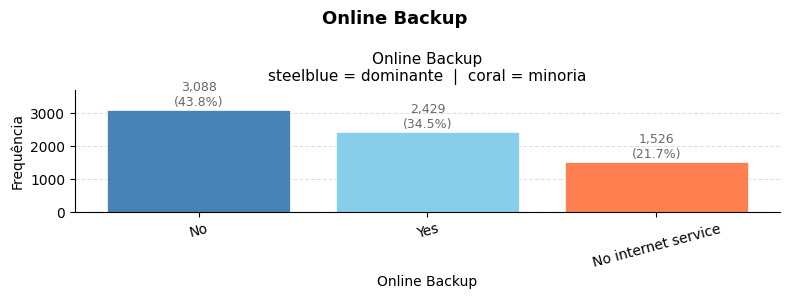

22:46:24 | INFO | Online Backup | n=7043 | nulos=0 | categorias=3 | dominante='No' (43.8%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_online_backup.png


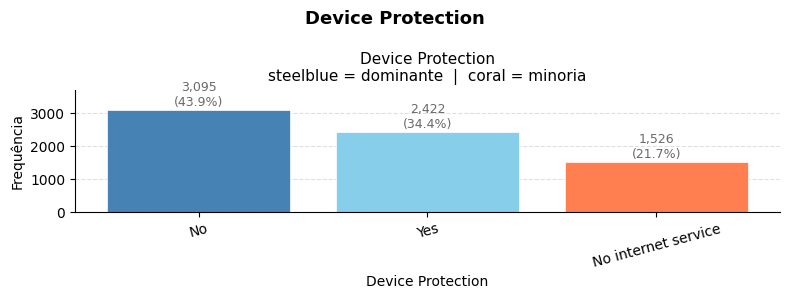

22:46:24 | INFO | Device Protection | n=7043 | nulos=0 | categorias=3 | dominante='No' (43.9%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:24 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_device_protection.png


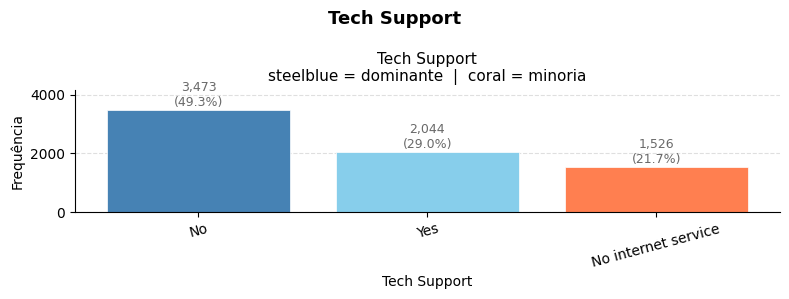

22:46:25 | INFO | Tech Support | n=7043 | nulos=0 | categorias=3 | dominante='No' (49.3%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_tech_support.png


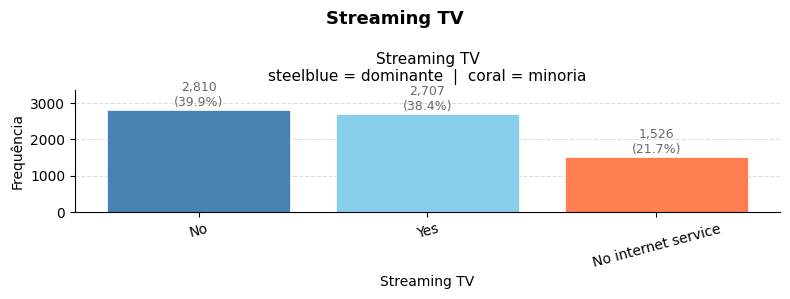

22:46:25 | INFO | Streaming TV | n=7043 | nulos=0 | categorias=3 | dominante='No' (39.9%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_streaming_tv.png


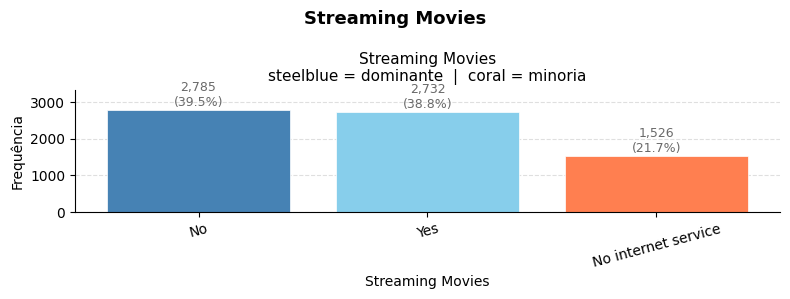

22:46:25 | INFO | Streaming Movies | n=7043 | nulos=0 | categorias=3 | dominante='No' (39.5%) | minoria='No internet service' (21.7%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_streaming_movies.png


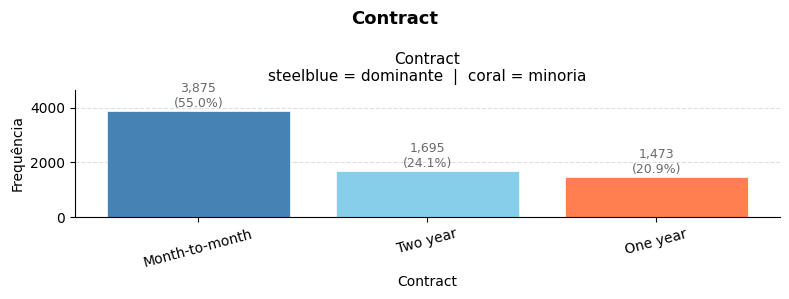

22:46:25 | INFO | Contract | n=7043 | nulos=0 | categorias=3 | dominante='Month-to-month' (55.0%) | minoria='One year' (20.9%) | dist_uniforme=33.3% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_contract.png


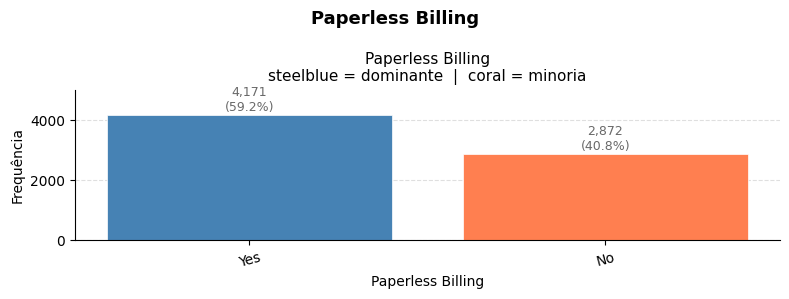

22:46:25 | INFO | Paperless Billing | n=7043 | nulos=0 | categorias=2 | dominante='Yes' (59.2%) | minoria='No' (40.8%) | dist_uniforme=50.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_paperless_billing.png


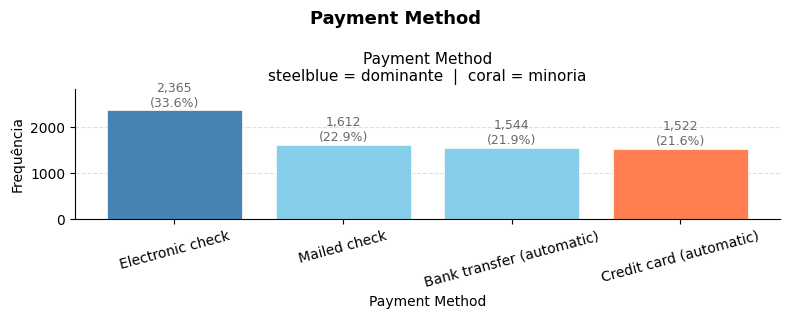

22:46:25 | INFO | Payment Method | n=7043 | nulos=0 | categorias=4 | dominante='Electronic check' (33.6%) | minoria='Credit card (automatic)' (21.6%) | dist_uniforme=25.0% | cats_raras=0 (<1%) | alta_concentracao=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_cat_payment_method.png
22:46:25 | INFO | Análise univariada finalizada para 16 variáveis categóricas.


In [145]:
logger.info("Análise univariada iniciada para %d variáveis categóricas.", len(COLS_CAT))
# ── EDA Univariada — Variáveis Categóricas ────────────────────────────────────
for col in COLS_CAT:
    series = df[col].dropna()
    freq_abs = series.value_counts()
    freq_rel = series.value_counts(normalize=True).mul(100).round(1)
    n_cats = series.nunique()
    n_nulos = df[col].isnull().sum()
    dominante = freq_abs.index[0]
    minoria = freq_abs.index[-1]

    # Anomalia: categoria com menos de 1% — dado raro ou erro de digitação
    cats_raras = freq_rel[freq_rel < 1.0]
    # Concentração: dominante > 80% — possível baixo poder preditivo
    alta_concentracao = freq_rel.iloc[0] > 80.0
    # Distribuição uniforme teórica — referência de equilíbrio entre categorias
    dist_uniforme = round(100 / n_cats, 1)

    # ── Plot ──────────────────────────────────────────────────────────────────
    altura = max(3, n_cats * 0.8)
    fig, ax = plt.subplots(figsize=(8, altura))
    fig.suptitle(col, fontsize=13, fontweight="bold")

    cores_barras = [
        CORES["secundaria"]
        if cat == dominante
        else CORES["destaque"]
        if cat == minoria
        else CORES["primaria"]
        for cat in freq_abs.index
    ]
    bars = ax.bar(
        freq_abs.index,
        freq_abs.values,
        color=cores_barras,
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )

    # Anotação no topo de cada barra: contagem absoluta + percentual
    for bar, count, pct in zip(bars, freq_abs.values, freq_rel.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + freq_abs.max() * 0.01,
            f"{count:,}\n({pct}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CORES["neutro"],
        )

    ax.set_title(
        f"{col}\nsteelblue = dominante  |  coral = minoria",
        fontsize=11,
    )
    ax.set_ylabel("Frequência")
    ax.set_xlabel(col)
    ax.set_ylim(0, freq_abs.max() * 1.2)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_UNIVARIADA / f"univariate_cat_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado por variável ──────────────────────────────────────────
    logger.info(
        "%s | n=%d | nulos=%d | categorias=%d | "
        "dominante='%s' (%.1f%%) | minoria='%s' (%.1f%%) | "
        "dist_uniforme=%.1f%% | cats_raras=%d (<1%%) | "
        "alta_concentracao=%s",
        col,
        len(series),
        n_nulos,
        n_cats,
        dominante,
        freq_rel.loc[dominante],
        minoria,
        freq_rel.loc[minoria],
        dist_uniforme,
        len(cats_raras),
        alta_concentracao,
    )

    # Alerta: categorias raras
    for cat, pct in cats_raras.items():
        logger.warning(
            "%s | categoria rara: '%s' = %.1f%% (%d registros)",
            col,
            cat,
            pct,
            freq_abs.loc[cat],
        )

    # Alerta: alta concentração
    if alta_concentracao:
        logger.warning(
            "%s | alta concentração: '%s' ocupa %.1f%% — avaliar poder preditivo",
            col,
            dominante,
            freq_rel.iloc[0],
        )

    logger.info("Artefato salvo: %s", output_path)

logger.info(
    "Análise univariada finalizada para %d variáveis categóricas.", len(COLS_CAT)
)

22:46:25 | INFO | Análise da assimetria e curtose iniciada para 3 variáveis numéricas.


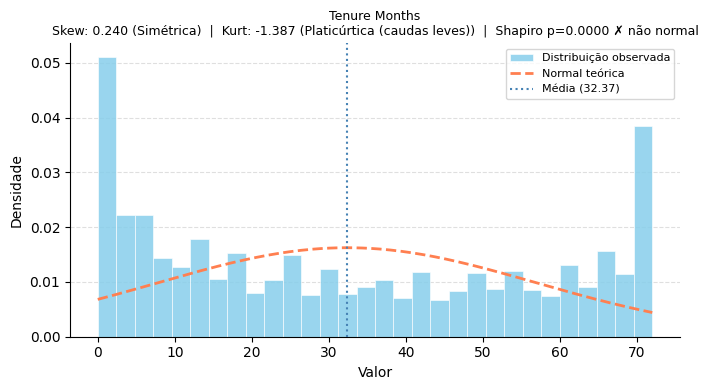

22:46:25 | INFO | Tenure Months | skewness=0.240 (Simétrica) | kurtosis=-1.387 (Platicúrtica (caudas leves)) | shapiro_p=0.0000 | normal=False
22:46:25 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_skew_kurt_tenure_months.png
22:46:25 | WARNING | Tenure Months | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


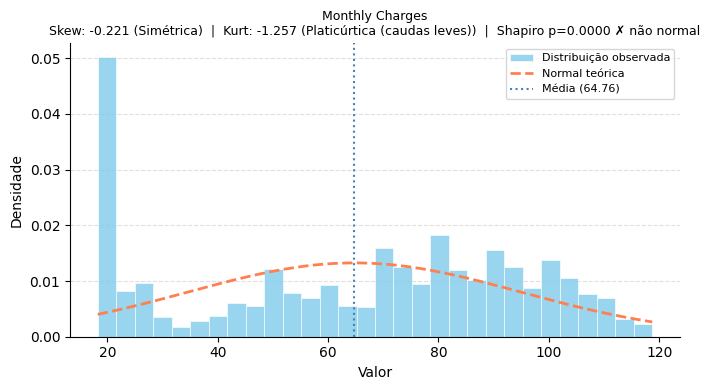

22:46:26 | INFO | Monthly Charges | skewness=-0.221 (Simétrica) | kurtosis=-1.257 (Platicúrtica (caudas leves)) | shapiro_p=0.0000 | normal=False
22:46:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_skew_kurt_monthly_charges.png
22:46:26 | WARNING | Monthly Charges | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


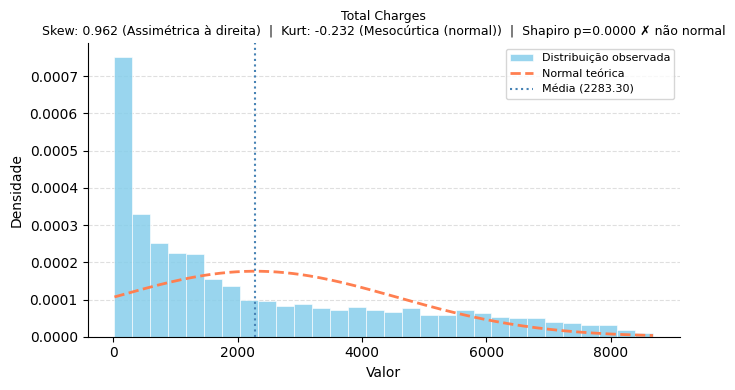

22:46:26 | INFO | Total Charges | skewness=0.962 (Assimétrica à direita) | kurtosis=-0.232 (Mesocúrtica (normal)) | shapiro_p=0.0000 | normal=False
22:46:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\univariada\univariate_skew_kurt_total_charges.png
22:46:26 | WARNING | Total Charges | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03
22:46:26 | INFO | Análise da assimetria e curtose finalizada para 3 variáveis numéricas.


In [146]:
logger.info(
    "Análise da assimetria e curtose iniciada para %d variáveis numéricas.",
    len(COLS_NUM),
)
# ── Assimetria e Curtose — Variáveis Numéricas ────────────────────────────────
distribution_stats = []

for col in COLS_NUM:
    series = df[col].dropna()
    skewness = series.skew()
    kurtosis = series.kurtosis()  # excess kurtosis (normal = 0)

    # Interpretação da assimetria
    if abs(skewness) < 0.5:
        interp_skew = "Simétrica"
    elif skewness > 0:
        interp_skew = "Assimétrica à direita"
    else:
        interp_skew = "Assimétrica à esquerda"

    # Interpretação da curtose (excess kurtosis)
    if abs(kurtosis) < 0.5:
        interp_kurt = "Mesocúrtica (normal)"
    elif kurtosis > 0:
        interp_kurt = "Leptocúrtica (caudas pesadas)"
    else:
        interp_kurt = "Platicúrtica (caudas leves)"

    # Teste de normalidade Shapiro-Wilk (amostra ≤ 5000)
    amostra = series.sample(min(len(series), 5000), random_state=RANDOM_STATE)
    _, p_valor = stats.shapiro(amostra)
    normal = p_valor > 0.05

    distribution_stats.append(
        {
            "Coluna": col,
            "Skewness": round(skewness, 3),
            "Kurtosis": round(kurtosis, 3),
            "Skew_interp": interp_skew,
            "Kurt_interp": interp_kurt,
            "Shapiro_p": round(p_valor, 4),
            "Normal": normal,
        }
    )

    # ── Plot: histograma + curva normal teórica sobreposta ────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(
        series,
        bins=30,
        color=CORES["primaria"],
        edgecolor="white",
        linewidth=0.5,
        density=True,  # normaliza para sobrepor curva teórica
        alpha=0.85,
        zorder=2,
        label="Distribuição observada",
    )

    # Curva normal teórica — referência visual para avaliar desvio da normalidade
    x = np.linspace(series.min(), series.max(), 200)
    curva_normal = stats.norm.pdf(x, series.mean(), series.std())
    ax.plot(
        x,
        curva_normal,
        color=CORES["destaque"],
        linewidth=2,
        linestyle="--",
        label="Normal teórica",
        zorder=3,
    )

    # Linha vertical na média
    ax.axvline(
        series.mean(),
        color=CORES["secundaria"],
        linewidth=1.5,
        linestyle=":",
        label=f"Média ({series.mean():.2f})",
        zorder=3,
    )

    ax.set_title(
        f"{col}\n"
        f"Skew: {skewness:.3f} ({interp_skew})  |  "
        f"Kurt: {kurtosis:.3f} ({interp_kurt})  |  "
        f"Shapiro p={p_valor:.4f} {'✓ normal' if normal else '✗ não normal'}",
        fontsize=9,
    )
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidade")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

    plt.tight_layout()
    output_path = (
        REPORTS_FIGURES_UNIVARIADA / f"univariate_skew_kurt_{col.lower().replace(' ', '_')}.png"
    )
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado por variável ──────────────────────────────────────────
    logger.info(
        "%s | skewness=%.3f (%s) | kurtosis=%.3f (%s) | shapiro_p=%.4f | normal=%s",
        col,
        skewness,
        interp_skew,
        kurtosis,
        interp_kurt,
        p_valor,
        normal,
    )
    logger.info("Artefato salvo: %s", output_path)

    # Alerta: não normalidade — relevante para escolha de transformações
    if not normal:
        logger.warning(
            "%s | distribuição não normal (Shapiro p=%.4f) — considerar log1p ou Box-Cox na Etapa 1.03",
            col,
            p_valor,
        )
logger.info(
    "Análise da assimetria e curtose finalizada para %d variáveis numéricas.",
    len(COLS_NUM),
)

## Análise univariada das features

### Descobertas Vitais: Variáveis Numéricas
A análise revelou comportamentos muito claros sobre as variáveis financeiras e de tempo de casa do cliente:

- A "Armadilha" dos Valores Nulos Ocultos: Observe o log com atenção. O dataset possui 7043 linhas, mas a variável Total Charges registrou n=7032. Isso significa que existem 11 valores nulos que precisam ser tratados. Como são clientes com Tenure = 0 (acabaram de assinar e ainda não pagaram o primeiro mês), a melhor estratégia costuma ser preencher esses nulos com 0.0.

- Ausência de Outliers Extremos: O log indica outliers_iqr=0 (0.00%) e outliers_zscore=0 (0.00%) para todas as três variáveis. Isso é uma excelente notícia! Significa que você não precisará aplicar técnicas drásticas de corte (clipping) ou usar algoritmos ultrarrobustos a outliers.

- Distribuições Não Normais (Assimetria e Curtose):  
  * O Teste de Shapiro-Wilk (p=0.0000) confirmou que nenhuma das três variáveis segue uma distribuição normal.  

  Tenure Months e Monthly Charges são platicúrticas (caudas leves, valores mais espalhados sem um pico central forte).  

  Total Charges possui uma forte assimetria à direita (skewness=0.962). Isso ocorre porque a maioria dos clientes tem cobranças totais baixas (estão há pouco tempo ou têm planos baratos), enquanto uma minoria acumula valores altíssimos ao longo dos anos.

---

### Descobertas Vitais: Variáveis Categóricas

O seu log processou 16 variáveis categóricas sem encontrar dados nulos ou categorias raras (abaixo de 1%), o que mostra uma base bem estruturada. No entanto, temos alertas importantes:

- Variáveis de Alta Concentração (Baixa Variância):

  Phone Service: 90.3% dos clientes possuem o serviço.  

  Senior Citizen: 83.8% não são idosos.  

  Alerta: Variáveis com quase toda a massa de dados em uma única categoria tendem a ter baixo poder preditivo. O modelo não consegue extrair padrões claros de diferenciação. Elas são fortes candidatas a serem descartadas após a análise bivariada, simplificando sua arquitetura.

- Distribuição de Contratos: O Contract do tipo Month-to-month domina 55.0% da base. Historicamente, em problemas de Telco, essa é a variável com maior peso preditivo para o Churn, pois não há barreira de saída (multa rescisória) para esses clientes.

---

## Insights e Plano de Ação para as Próximas Etapas

Com base nesses dados, aqui estão as diretrizes técnicas que você deve levar para a construção do seu pipeline no Scikit-Learn e PyTorch:

- Transformação de Dados (Pipeline Sklearn):

  Como sugerido pelo seu próprio log, aplique uma transformação matemática (como np.log1p ou PowerTransformer do tipo Box-Cox/Yeo-Johnson) nas variáveis numéricas, especialmente em Total Charges, para reduzir a assimetria à direita.  

  Após a transformação, aplique um StandardScaler ou MinMaxScaler. Redes Neurais (MLP) são extremamente sensíveis à escala das features; alimentá-las com valores brutos de Total Charges na casa dos milhares causará instabilidade no gradiente.

- Tratamento de Categóricas:

  Para as variáveis binárias (como Partner, Dependents, Paperless Billing), utilize um OrdinalEncoder ou mapeamento simples para 0 e 1.  

  Para as variáveis multiclasse sem hierarquia (como Payment Method, Internet Service), aplique OneHotEncoder.

- Validação de Hipóteses (Preparação para Bivariada):

  A próxima etapa natural é cruzar essas variáveis com o nosso alvo (Churn). A alta concentração de Phone Service realmente importa para o Churn, ou podemos focar apenas no tipo de Internet Service?

22:46:26 | INFO | Análise bivariada avançada iniciada para 3 variáveis numéricas.
C:\Users\victo\AppData\Local\Temp\ipykernel_28412\1492304207.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series.groupby(bins)[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_28412\1492304207.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


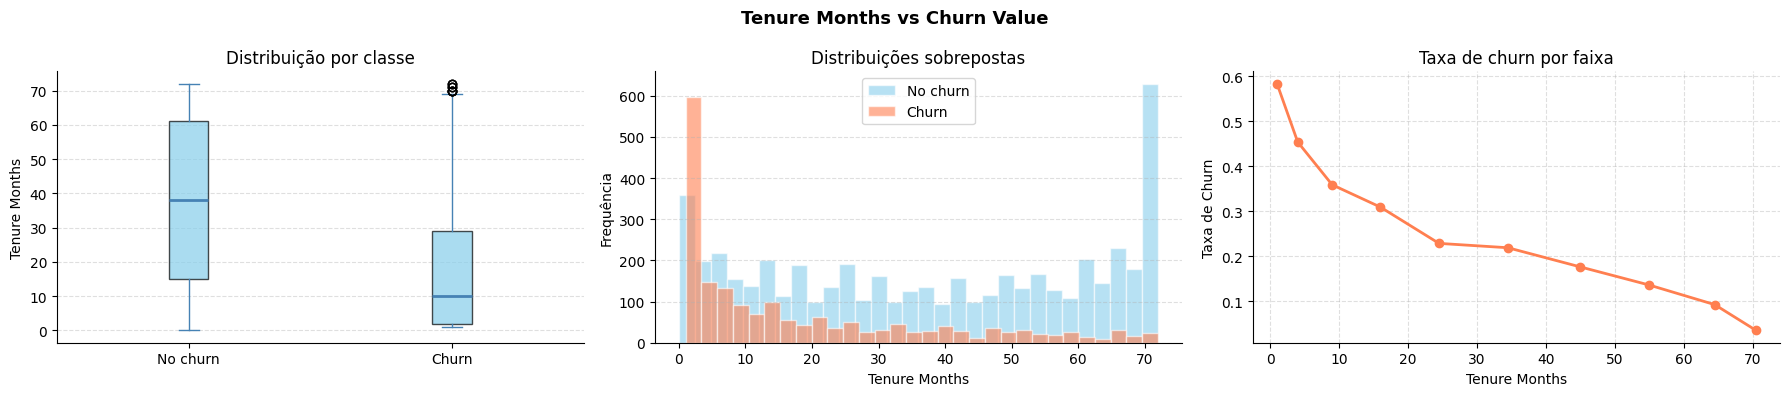

22:46:26 | INFO | Tenure Months | n0=5174 | n1=1869 | mean_0=37.57 | mean_1=17.98 | median_0=38.00 | median_1=10.00 | std_0=24.11 | std_1=19.53 | corr=-0.3522 | cohen_d=-0.8928 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=23 (1.23%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=0 (0.00%)
22:46:26 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_num_tenure months.png
C:\Users\victo\AppData\Local\Temp\ipykernel_28412\1492304207.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series.groupby(bins)[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_28412\1492304207.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has

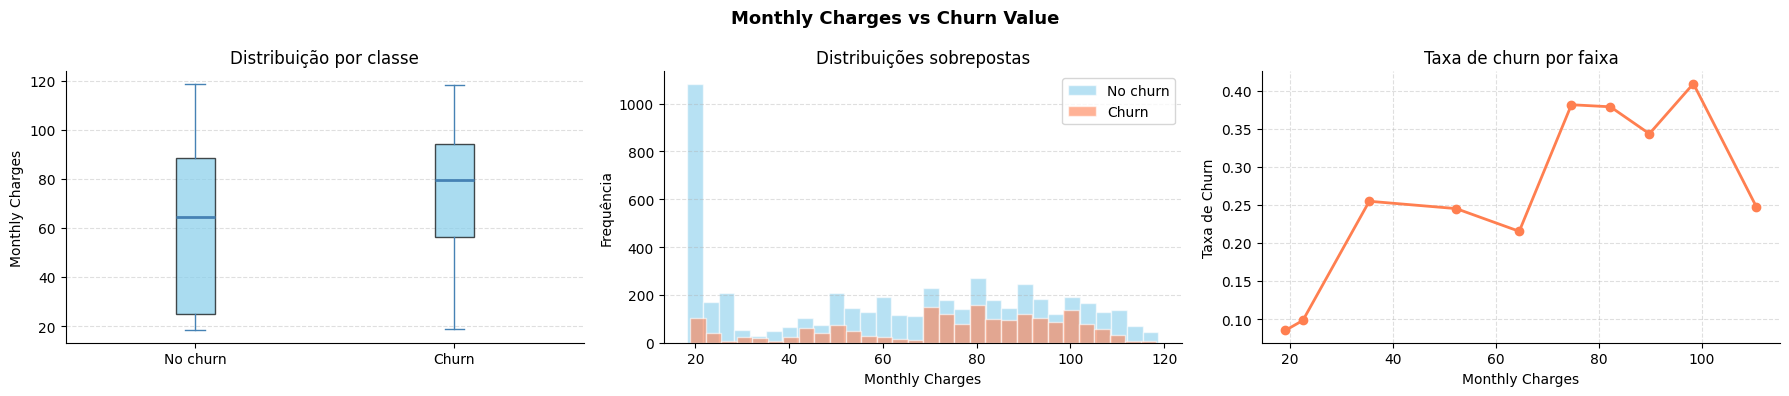

22:46:27 | INFO | Monthly Charges | n0=5174 | n1=1869 | mean_0=61.27 | mean_1=74.44 | median_0=64.43 | median_1=79.65 | std_0=31.09 | std_1=24.67 | corr=0.1934 | cohen_d=0.4695 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=0 (0.00%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=0 (0.00%)
22:46:27 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_num_monthly charges.png
C:\Users\victo\AppData\Local\Temp\ipykernel_28412\1492304207.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = series.groupby(bins)[TARGET].mean()
C:\Users\victo\AppData\Local\Temp\ipykernel_28412\1492304207.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() ha

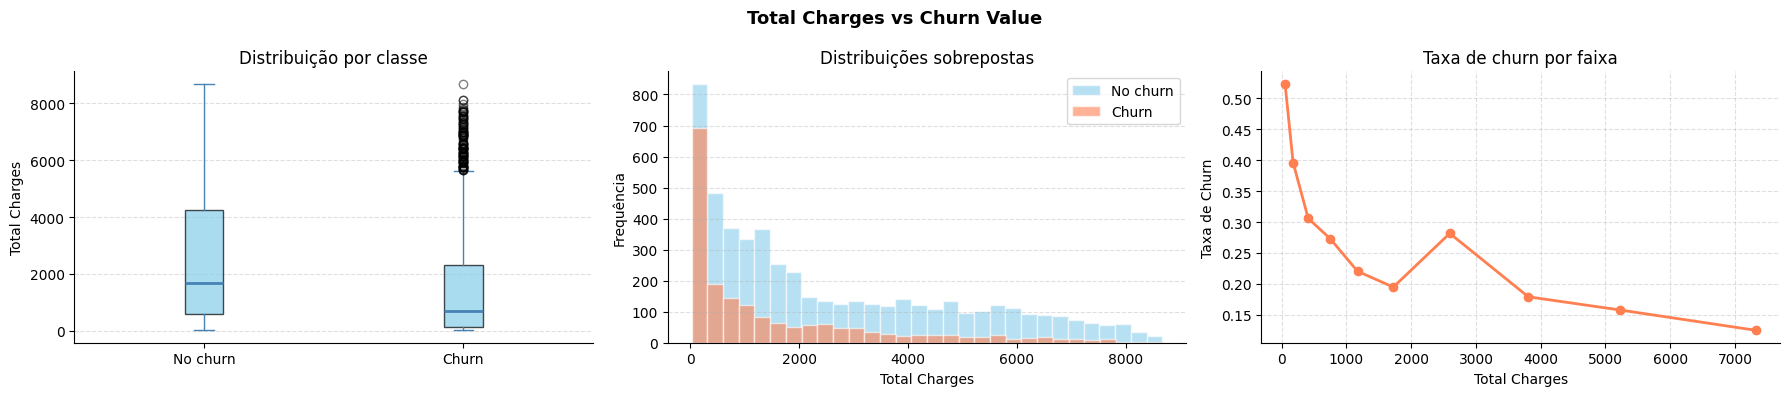

22:46:27 | INFO | Total Charges | n0=5163 | n1=1869 | mean_0=2555.34 | mean_1=1531.80 | median_0=1683.60 | median_1=703.55 | std_0=2329.46 | std_1=1890.82 | corr=-0.1995 | cohen_d=-0.4825 | p_value=0.000000 | grp0_outliers_iqr=0 (0.00%) | grp1_outliers_iqr=109 (5.83%) | grp0_outliers_z=0 (0.00%) | grp1_outliers_z=27 (1.44%)
22:46:27 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_num_total charges.png
22:46:27 | INFO | Análise bivariada avançada finalizada.


In [147]:
logger.info(
    "Análise bivariada avançada iniciada para %d variáveis numéricas.", len(COLS_NUM)
)


for col in COLS_NUM:
    series = df[[col, TARGET]].dropna()

    grp_0 = series[series[TARGET] == 0][col]
    grp_1 = series[series[TARGET] == 1][col]

    # ── Função para outliers ─────────────────────────────────────────────
    def compute_outliers(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        mask_iqr = (s < lim_inf) | (s > lim_sup)
        n_iqr = mask_iqr.sum()
        pct_iqr = n_iqr / len(s) * 100

        z_scores = np.abs(stats.zscore(s))
        mask_z = z_scores > 3
        n_z = mask_z.sum()
        pct_z = n_z / len(s) * 100

        return {
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lim_inf": lim_inf,
            "lim_sup": lim_sup,
            "n_iqr": n_iqr,
            "pct_iqr": pct_iqr,
            "n_z": n_z,
            "pct_z": pct_z,
        }

    out_0 = compute_outliers(grp_0)
    out_1 = compute_outliers(grp_1)

    # ── Estatísticas ─────────────────────────────────────────────────────
    mean_0, mean_1 = grp_0.mean(), grp_1.mean()
    med_0, med_1 = grp_0.median(), grp_1.median()
    std_0, std_1 = grp_0.std(), grp_1.std()

    stat, p_value = stats.mannwhitneyu(grp_0, grp_1)

    pooled_std = np.sqrt((std_0**2 + std_1**2) / 2)
    cohen_d = (mean_1 - mean_0) / pooled_std if pooled_std != 0 else 0

    corr = series[col].corr(series[TARGET])

    # ── Curva de churn (binning) ─────────────────────────────────────────
    bins = pd.qcut(series[col], q=10, duplicates="drop")
    churn_rate = series.groupby(bins)[TARGET].mean()
    bin_centers = [interval.mid for interval in churn_rate.index]

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{col} vs {TARGET}", fontsize=13, fontweight="bold")

    # 🔹 Boxplot
    axes[0].boxplot(
        [grp_0, grp_1],
        labels=["No churn", "Churn"],
        patch_artist=True,
        boxprops=dict(facecolor=CORES["primaria"], alpha=0.7),
        medianprops=dict(color=CORES["secundaria"], linewidth=2),
        whiskerprops=dict(color=CORES["secundaria"]),
        capprops=dict(color=CORES["secundaria"]),
        flierprops=dict(marker="o", color=CORES["alerta"], alpha=0.5),
    )
    axes[0].set_title("Distribuição por classe")
    axes[0].set_ylabel(col)
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].spines[["top", "right"]].set_visible(False)

    # 🔹 Histograma
    axes[1].hist(
        grp_0,
        bins=30,
        alpha=0.6,
        label="No churn",
        color=CORES["primaria"],
        edgecolor="white",
    )
    axes[1].hist(
        grp_1,
        bins=30,
        alpha=0.6,
        label="Churn",
        color=CORES["destaque"],
        edgecolor="white",
    )
    axes[1].set_title("Distribuições sobrepostas")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequência")
    axes[1].legend()
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].spines[["top", "right"]].set_visible(False)

    # 🔹 Linha (churn rate)
    axes[2].plot(
        bin_centers, churn_rate.values, marker="o", color=CORES["destaque"], linewidth=2
    )
    axes[2].set_title("Taxa de churn por faixa")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("Taxa de Churn")
    axes[2].grid(True, linestyle="--", alpha=0.4)
    axes[2].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    output_path = REPORTS_FIGURES_MULTIVARIADA / f"bivariate_num_{col.lower()}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado ───────────────────────────────────────────────────
    logger.info(
        "%s | "
        "n0=%d | n1=%d | "
        "mean_0=%.2f | mean_1=%.2f | "
        "median_0=%.2f | median_1=%.2f | "
        "std_0=%.2f | std_1=%.2f | "
        "corr=%.4f | cohen_d=%.4f | p_value=%.6f | "
        "grp0_outliers_iqr=%d (%.2f%%) | grp1_outliers_iqr=%d (%.2f%%) | "
        "grp0_outliers_z=%d (%.2f%%) | grp1_outliers_z=%d (%.2f%%)",
        col,
        len(grp_0),
        len(grp_1),
        mean_0,
        mean_1,
        med_0,
        med_1,
        std_0,
        std_1,
        corr,
        cohen_d,
        p_value,
        out_0["n_iqr"],
        out_0["pct_iqr"],
        out_1["n_iqr"],
        out_1["pct_iqr"],
        out_0["n_z"],
        out_0["pct_z"],
        out_1["n_z"],
        out_1["pct_z"],
    )

    logger.info("Artefato salvo: %s", output_path)

logger.info("Análise bivariada avançada finalizada.")

22:46:27 | INFO | Análise bivariada iniciada para 16 variáveis categóricas.


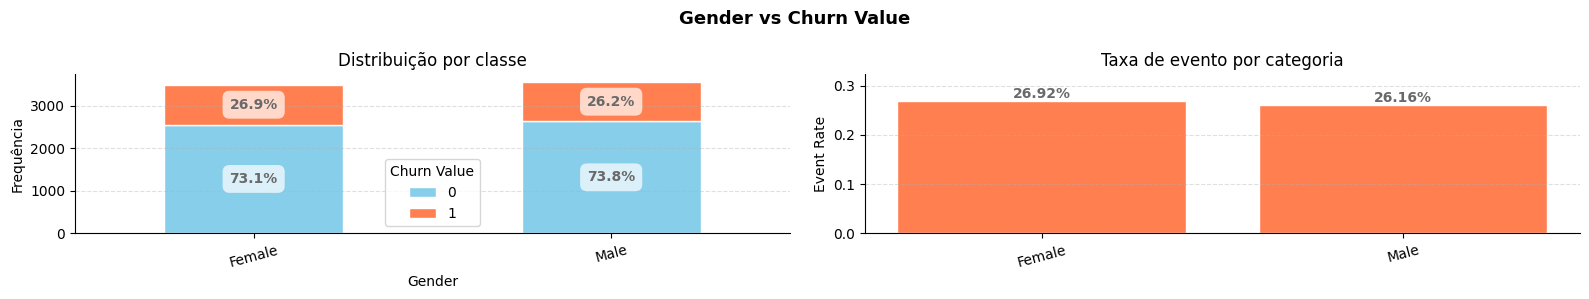

22:46:27 | INFO | Gender | n=7043 | n_cats=2 | dominante='Male' (50.5%) | minoria='Female' (49.5%) | chi2=0.4841 | p_value=0.486579 | cramer_v=0.0083
22:46:27 | INFO | Gender | categoria='Female' | n=3488 | n0=2549 | n1=939 | event_rate=0.2692
22:46:27 | INFO | Gender | categoria='Male' | n=3555 | n0=2625 | n1=930 | event_rate=0.2616
22:46:27 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_gender.png


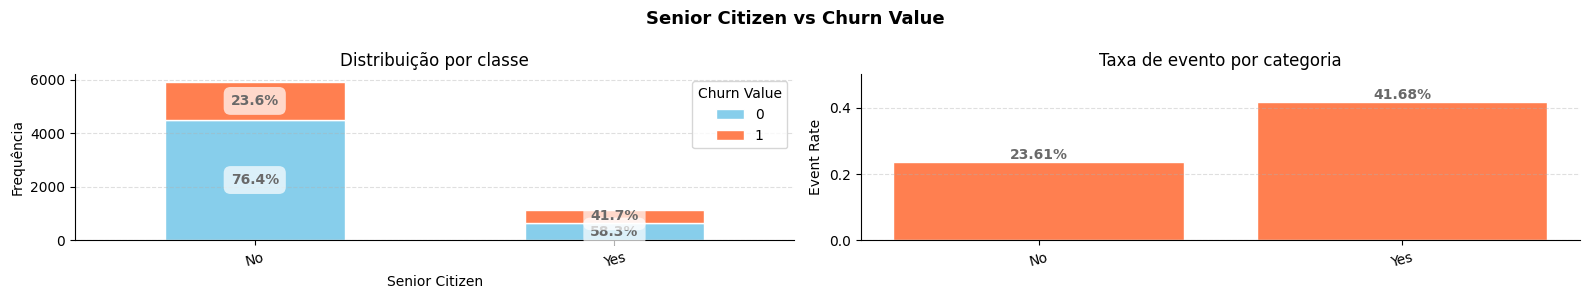

22:46:28 | INFO | Senior Citizen | n=7043 | n_cats=2 | dominante='No' (83.8%) | minoria='Yes' (16.2%) | chi2=159.4263 | p_value=0.000000 | cramer_v=0.1505
22:46:28 | INFO | Senior Citizen | categoria='No' | n=5901 | n0=4508 | n1=1393 | event_rate=0.2361
22:46:28 | INFO | Senior Citizen | categoria='Yes' | n=1142 | n0=666 | n1=476 | event_rate=0.4168
22:46:28 | WARNING | Senior Citizen | alta concentração: 'No' ocupa 83.8% — avaliar poder preditivo
22:46:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_senior_citizen.png


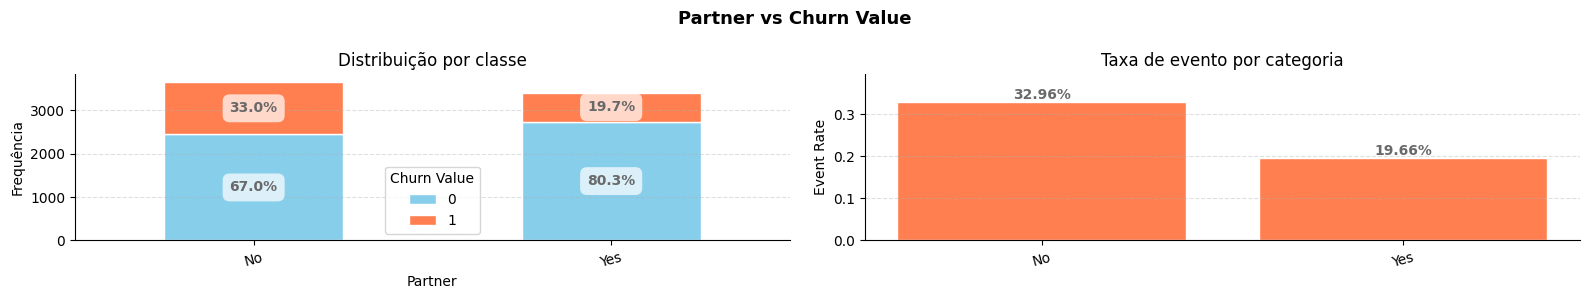

22:46:28 | INFO | Partner | n=7043 | n_cats=2 | dominante='No' (51.7%) | minoria='Yes' (48.3%) | chi2=158.7334 | p_value=0.000000 | cramer_v=0.1501
22:46:28 | INFO | Partner | categoria='No' | n=3641 | n0=2441 | n1=1200 | event_rate=0.3296
22:46:28 | INFO | Partner | categoria='Yes' | n=3402 | n0=2733 | n1=669 | event_rate=0.1966
22:46:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_partner.png


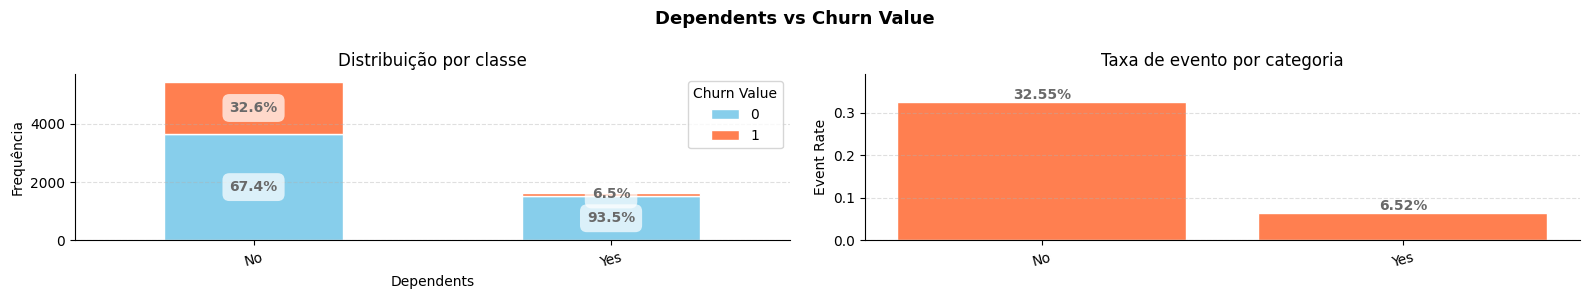

22:46:28 | INFO | Dependents | n=7043 | n_cats=2 | dominante='No' (76.9%) | minoria='Yes' (23.1%) | chi2=433.7344 | p_value=0.000000 | cramer_v=0.2482
22:46:28 | INFO | Dependents | categoria='No' | n=5416 | n0=3653 | n1=1763 | event_rate=0.3255
22:46:28 | INFO | Dependents | categoria='Yes' | n=1627 | n0=1521 | n1=106 | event_rate=0.0652
22:46:28 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_dependents.png


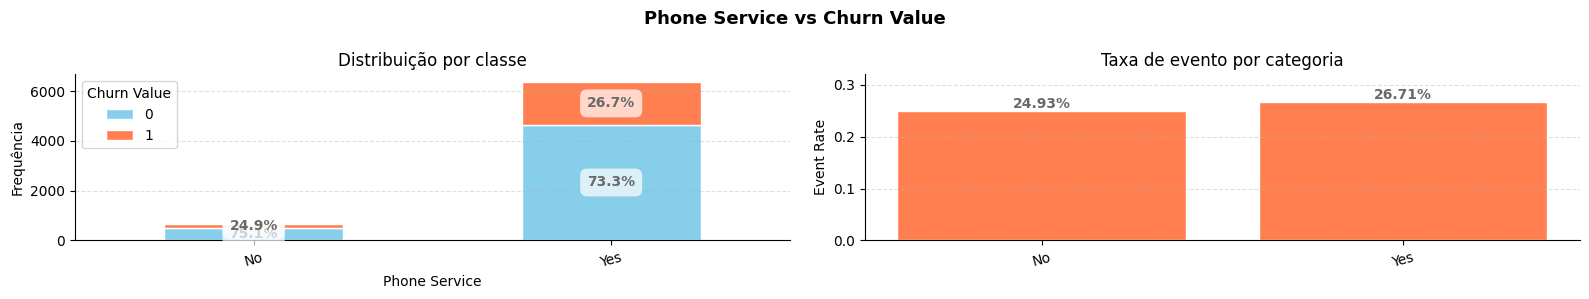

22:46:29 | INFO | Phone Service | n=7043 | n_cats=2 | dominante='Yes' (90.3%) | minoria='No' (9.7%) | chi2=0.9150 | p_value=0.338783 | cramer_v=0.0114
22:46:29 | INFO | Phone Service | categoria='No' | n=682 | n0=512 | n1=170 | event_rate=0.2493
22:46:29 | INFO | Phone Service | categoria='Yes' | n=6361 | n0=4662 | n1=1699 | event_rate=0.2671
22:46:29 | WARNING | Phone Service | alta concentração: 'Yes' ocupa 90.3% — avaliar poder preditivo
22:46:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_phone_service.png


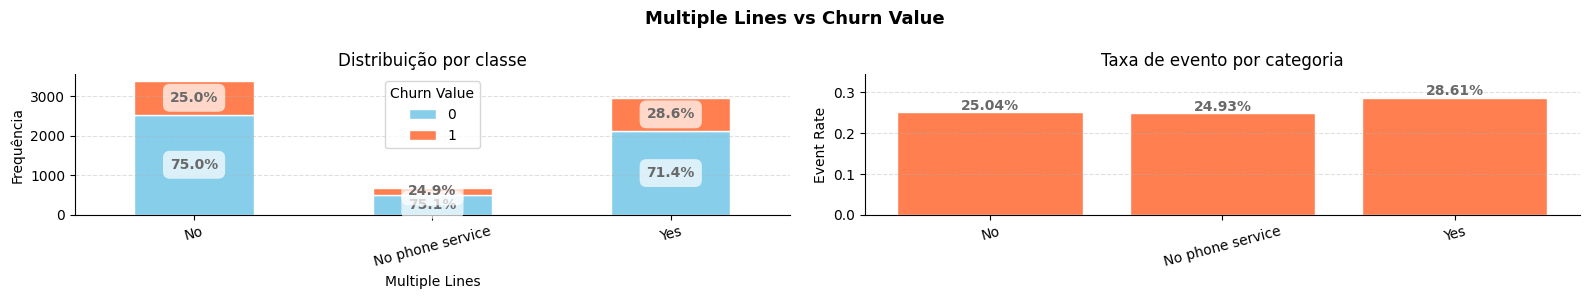

22:46:29 | INFO | Multiple Lines | n=7043 | n_cats=3 | dominante='No' (48.1%) | minoria='No phone service' (9.7%) | chi2=11.3304 | p_value=0.003464 | cramer_v=0.0401
22:46:29 | INFO | Multiple Lines | categoria='No' | n=3390 | n0=2541 | n1=849 | event_rate=0.2504
22:46:29 | INFO | Multiple Lines | categoria='No phone service' | n=682 | n0=512 | n1=170 | event_rate=0.2493
22:46:29 | INFO | Multiple Lines | categoria='Yes' | n=2971 | n0=2121 | n1=850 | event_rate=0.2861
22:46:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_multiple_lines.png


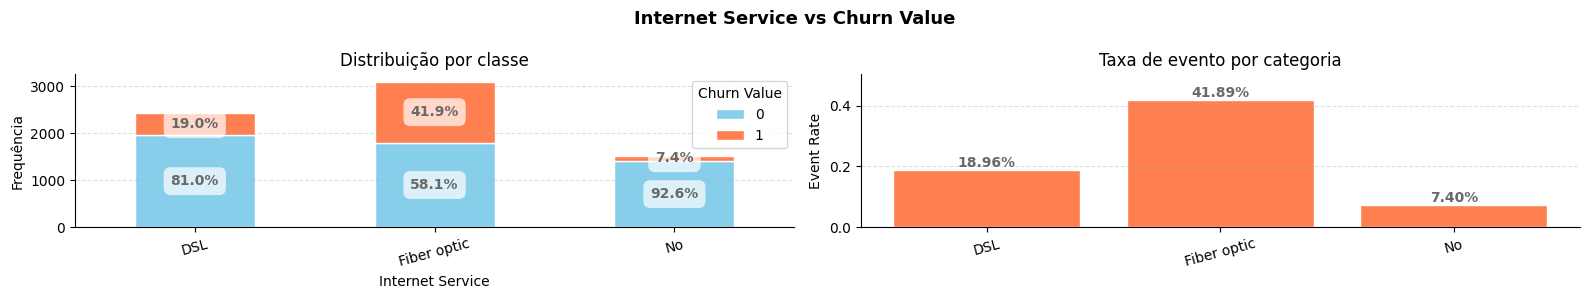

22:46:29 | INFO | Internet Service | n=7043 | n_cats=3 | dominante='Fiber optic' (44.0%) | minoria='No' (21.7%) | chi2=732.3096 | p_value=0.000000 | cramer_v=0.3225
22:46:29 | INFO | Internet Service | categoria='DSL' | n=2421 | n0=1962 | n1=459 | event_rate=0.1896
22:46:29 | INFO | Internet Service | categoria='Fiber optic' | n=3096 | n0=1799 | n1=1297 | event_rate=0.4189
22:46:29 | INFO | Internet Service | categoria='No' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_internet_service.png


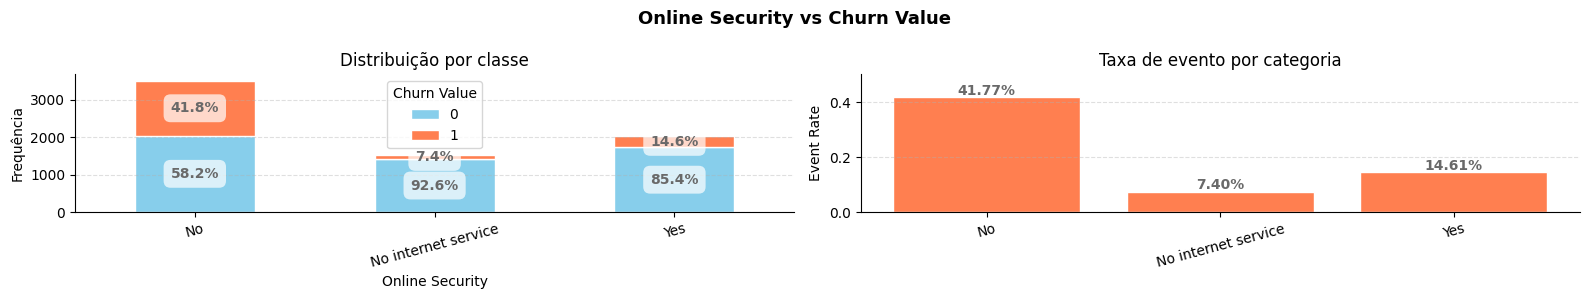

22:46:29 | INFO | Online Security | n=7043 | n_cats=3 | dominante='No' (49.7%) | minoria='No internet service' (21.7%) | chi2=849.9990 | p_value=0.000000 | cramer_v=0.3474
22:46:29 | INFO | Online Security | categoria='No' | n=3498 | n0=2037 | n1=1461 | event_rate=0.4177
22:46:29 | INFO | Online Security | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:29 | INFO | Online Security | categoria='Yes' | n=2019 | n0=1724 | n1=295 | event_rate=0.1461
22:46:29 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_online_security.png


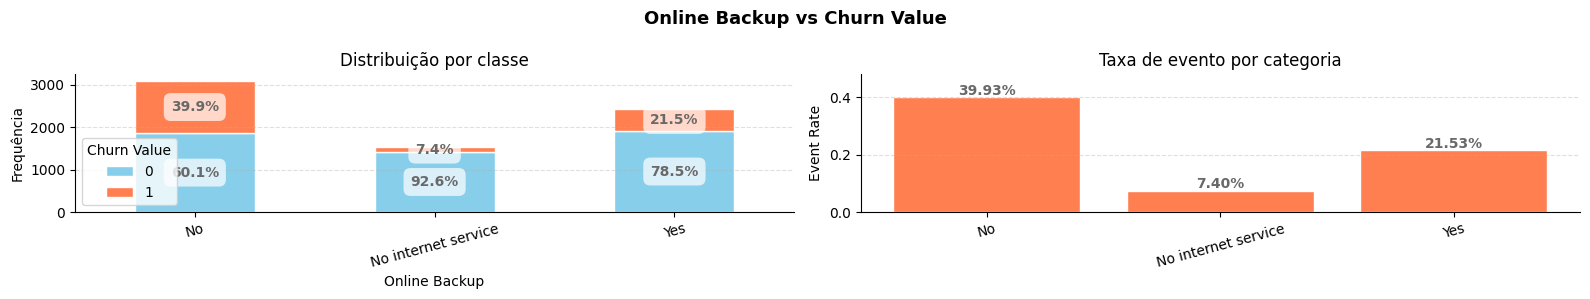

22:46:30 | INFO | Online Backup | n=7043 | n_cats=3 | dominante='No' (43.8%) | minoria='No internet service' (21.7%) | chi2=601.8128 | p_value=0.000000 | cramer_v=0.2923
22:46:30 | INFO | Online Backup | categoria='No' | n=3088 | n0=1855 | n1=1233 | event_rate=0.3993
22:46:30 | INFO | Online Backup | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:30 | INFO | Online Backup | categoria='Yes' | n=2429 | n0=1906 | n1=523 | event_rate=0.2153
22:46:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_online_backup.png


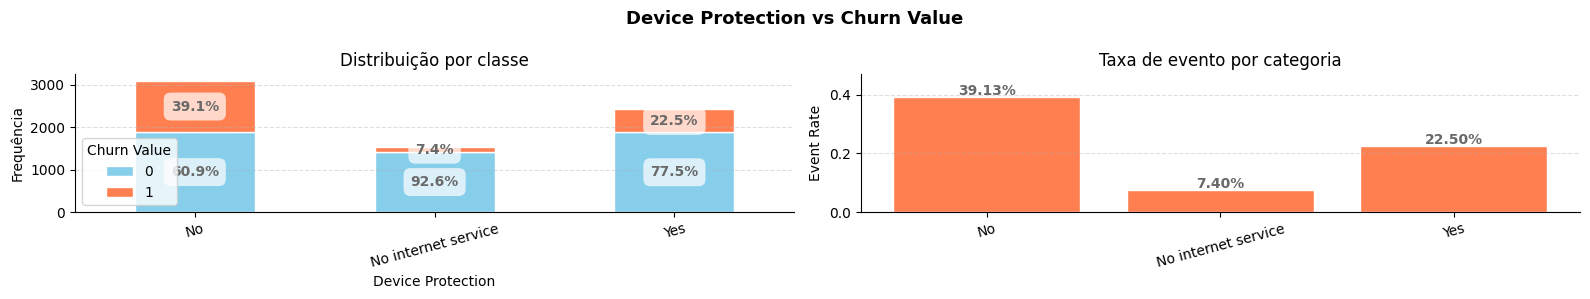

22:46:30 | INFO | Device Protection | n=7043 | n_cats=3 | dominante='No' (43.9%) | minoria='No internet service' (21.7%) | chi2=558.4194 | p_value=0.000000 | cramer_v=0.2816
22:46:30 | INFO | Device Protection | categoria='No' | n=3095 | n0=1884 | n1=1211 | event_rate=0.3913
22:46:30 | INFO | Device Protection | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:30 | INFO | Device Protection | categoria='Yes' | n=2422 | n0=1877 | n1=545 | event_rate=0.2250
22:46:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_device_protection.png


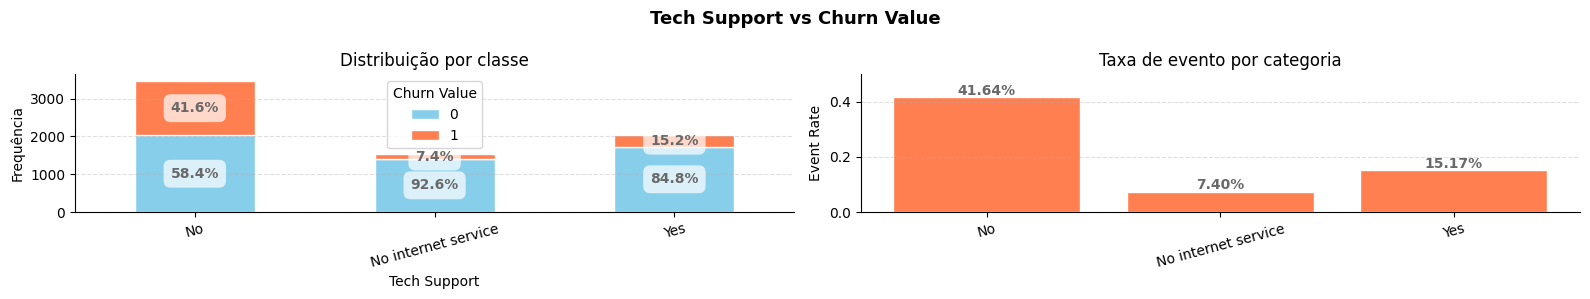

22:46:30 | INFO | Tech Support | n=7043 | n_cats=3 | dominante='No' (49.3%) | minoria='No internet service' (21.7%) | chi2=828.1971 | p_value=0.000000 | cramer_v=0.3429
22:46:30 | INFO | Tech Support | categoria='No' | n=3473 | n0=2027 | n1=1446 | event_rate=0.4164
22:46:30 | INFO | Tech Support | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:30 | INFO | Tech Support | categoria='Yes' | n=2044 | n0=1734 | n1=310 | event_rate=0.1517
22:46:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_tech_support.png


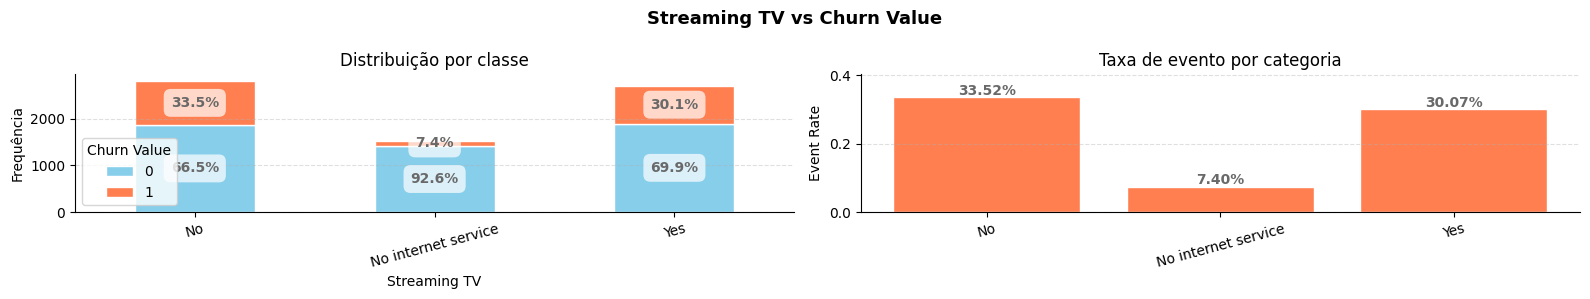

22:46:30 | INFO | Streaming TV | n=7043 | n_cats=3 | dominante='No' (39.9%) | minoria='No internet service' (21.7%) | chi2=374.2039 | p_value=0.000000 | cramer_v=0.2305
22:46:30 | INFO | Streaming TV | categoria='No' | n=2810 | n0=1868 | n1=942 | event_rate=0.3352
22:46:30 | INFO | Streaming TV | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:30 | INFO | Streaming TV | categoria='Yes' | n=2707 | n0=1893 | n1=814 | event_rate=0.3007
22:46:30 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_streaming_tv.png


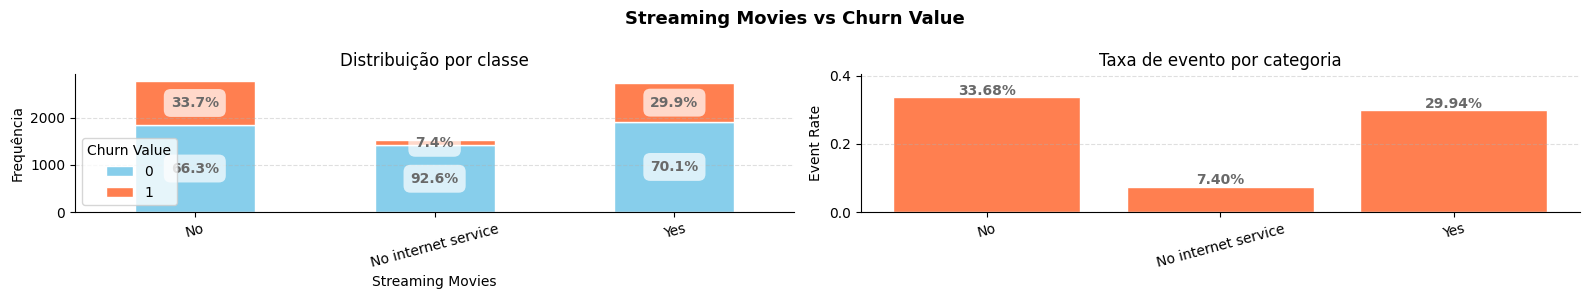

22:46:31 | INFO | Streaming Movies | n=7043 | n_cats=3 | dominante='No' (39.5%) | minoria='No internet service' (21.7%) | chi2=375.6615 | p_value=0.000000 | cramer_v=0.2310
22:46:31 | INFO | Streaming Movies | categoria='No' | n=2785 | n0=1847 | n1=938 | event_rate=0.3368
22:46:31 | INFO | Streaming Movies | categoria='No internet service' | n=1526 | n0=1413 | n1=113 | event_rate=0.0740
22:46:31 | INFO | Streaming Movies | categoria='Yes' | n=2732 | n0=1914 | n1=818 | event_rate=0.2994
22:46:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_streaming_movies.png


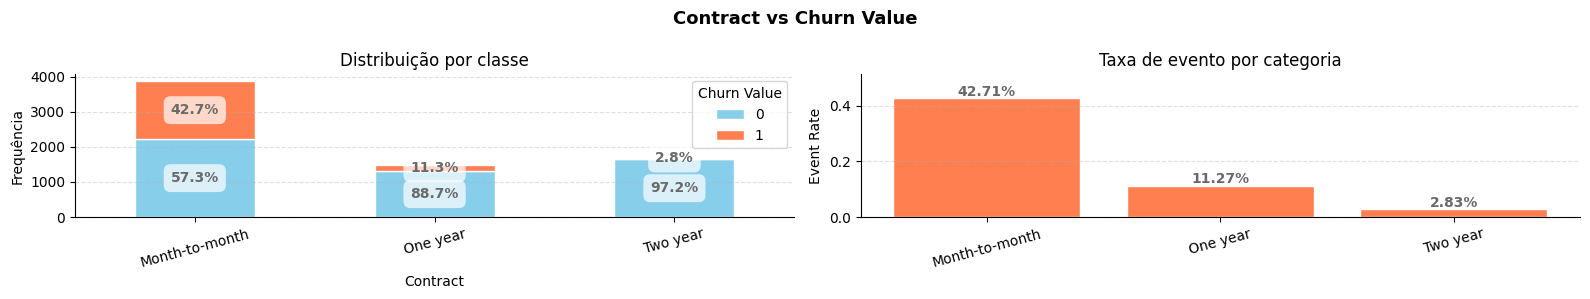

22:46:31 | INFO | Contract | n=7043 | n_cats=3 | dominante='Month-to-month' (55.0%) | minoria='One year' (20.9%) | chi2=1184.5966 | p_value=0.000000 | cramer_v=0.4101
22:46:31 | INFO | Contract | categoria='Month-to-month' | n=3875 | n0=2220 | n1=1655 | event_rate=0.4271
22:46:31 | INFO | Contract | categoria='One year' | n=1473 | n0=1307 | n1=166 | event_rate=0.1127
22:46:31 | INFO | Contract | categoria='Two year' | n=1695 | n0=1647 | n1=48 | event_rate=0.0283
22:46:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_contract.png


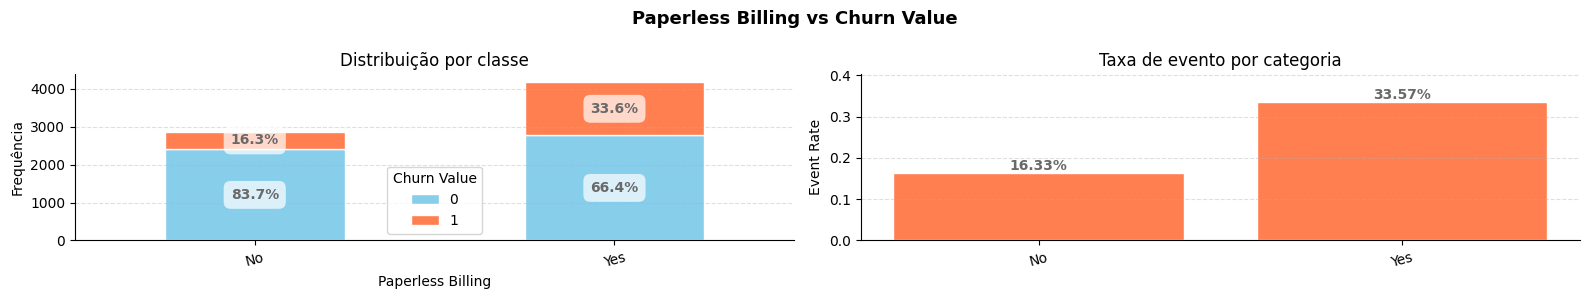

22:46:31 | INFO | Paperless Billing | n=7043 | n_cats=2 | dominante='Yes' (59.2%) | minoria='No' (40.8%) | chi2=258.2776 | p_value=0.000000 | cramer_v=0.1915
22:46:31 | INFO | Paperless Billing | categoria='No' | n=2872 | n0=2403 | n1=469 | event_rate=0.1633
22:46:31 | INFO | Paperless Billing | categoria='Yes' | n=4171 | n0=2771 | n1=1400 | event_rate=0.3357
22:46:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_paperless_billing.png


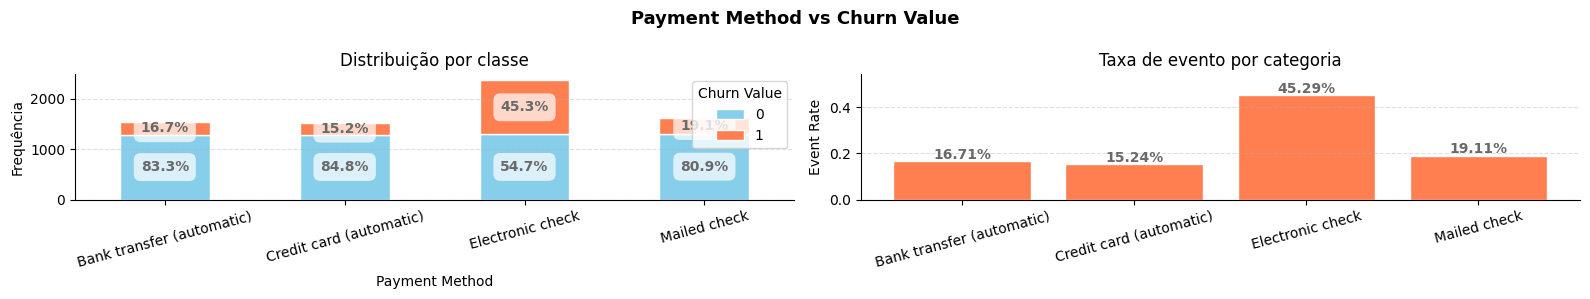

22:46:31 | INFO | Payment Method | n=7043 | n_cats=4 | dominante='Electronic check' (33.6%) | minoria='Credit card (automatic)' (21.6%) | chi2=648.1423 | p_value=0.000000 | cramer_v=0.3034
22:46:31 | INFO | Payment Method | categoria='Bank transfer (automatic)' | n=1544 | n0=1286 | n1=258 | event_rate=0.1671
22:46:31 | INFO | Payment Method | categoria='Credit card (automatic)' | n=1522 | n0=1290 | n1=232 | event_rate=0.1524
22:46:31 | INFO | Payment Method | categoria='Electronic check' | n=2365 | n0=1294 | n1=1071 | event_rate=0.4529
22:46:31 | INFO | Payment Method | categoria='Mailed check' | n=1612 | n0=1304 | n1=308 | event_rate=0.1911
22:46:31 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\bivariate_cat_payment_method.png
22:46:31 | INFO | Análise bivariada finalizada para 16 variáveis categóricas.


In [148]:
logger.info("Análise bivariada iniciada para %d variáveis categóricas.", len(COLS_CAT))


for col in COLS_CAT:
    series = df[[col, TARGET]].dropna()

    # ── Frequência geral ────────────────────────────────────────────────
    freq_abs = series[col].value_counts()
    freq_rel = series[col].value_counts(normalize=True).mul(100).round(1)

    n_cats = series[col].nunique()
    n_total = len(series)

    dominante = freq_abs.index[0]
    minoria = freq_abs.index[-1]

    # ── Crosstab (base da análise bivariada) ────────────────────────────
    crosstab = pd.crosstab(series[col], series[TARGET])

    # Garantir colunas 0 e 1
    if 0 not in crosstab.columns:
        crosstab[0] = 0
    if 1 not in crosstab.columns:
        crosstab[1] = 0

    crosstab = crosstab[[0, 1]]

    # ── Taxa de evento (churn rate) ─────────────────────────────────────
    churn_rate = (crosstab[1] / (crosstab[0] + crosstab[1])).fillna(0)

    # ── Estatística: Chi-quadrado ───────────────────────────────────────
    chi2, p_value, _, _ = chi2_contingency(crosstab)

    # ── Cramér's V (força da associação) ────────────────────────────────
    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    cramer_v = np.sqrt(phi2 / min(k - 1, r - 1)) if min(k - 1, r - 1) > 0 else 0

    # ── Categorias raras e concentração ────────────────────────────────
    cats_raras = freq_rel[freq_rel < 1.0]
    alta_concentracao = freq_rel.iloc[0] > 80.0

    # ── Plot (2 gráficos) ──────────────────────────────────────────────
    altura = max(3, n_cats * 0.6)
    fig, axes = plt.subplots(1, 2, figsize=(16, altura))
    fig.suptitle(f"{col} vs {TARGET}", fontsize=13, fontweight="bold")

    # Distribuição absoluta (stacked)
    bars = crosstab.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        color=[CORES["primaria"], CORES["destaque"]],
        edgecolor="white",
    )

    axes[0].set_title("Distribuição por classe")
    axes[0].set_ylabel("Frequência")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[0].spines[["top", "right"]].set_visible(False)

    # ── Anotação em % dentro das barras ─────────────────────────────
    for i, cat in enumerate(crosstab.index):
        n0 = crosstab.loc[cat, 0]
        n1 = crosstab.loc[cat, 1]
        total = n0 + n1

        pct_0 = n0 / total if total > 0 else 0
        pct_1 = n1 / total if total > 0 else 0

        # posição vertical
        y0 = n0 / 2
        y1 = n0 + (n1 / 2)

        # texto No Churn
        axes[0].text(
            i,
            y0,
            f"{pct_0:.1%}",
            ha="center",
            va="center",
            fontsize=10,
            color=CORES["neutro"],
            fontweight="bold",
            bbox=dict(
                facecolor="white",  # fundo (pode usar CORES["neutro"] com alpha)
                edgecolor="none",
                boxstyle="round,pad=0.5",  # 👈 PADDING aqui
                alpha=0.7,
            ),
        )

        # texto Churn
        axes[0].text(
            i,
            y1,
            f"{pct_1:.1%}",
            ha="center",
            va="center",
            fontsize=10,
            color=CORES["neutro"],
            fontweight="bold",
            bbox=dict(
                facecolor="white", edgecolor="none", boxstyle="round,pad=0.5", alpha=0.7
            ),
        )

    # Taxa de churn por categoria (ESSENCIAL)
    axes[1].bar(
        churn_rate.index, churn_rate.values, color=CORES["destaque"], edgecolor="white"
    )
    axes[1].set_title("Taxa de evento por categoria")
    axes[1].set_ylabel("Event Rate")
    axes[1].set_ylim(0, churn_rate.max() * 1.2)
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)
    axes[1].spines[["top", "right"]].set_visible(False)

    # Anotar % em cima das barras
    for i, v in enumerate(churn_rate.values):
        axes[1].text(
            i,
            v + churn_rate.max() * 0.02,
            f"{v:.2%}",
            ha="center",
            fontsize=10,
            color=CORES["neutro"],
            fontweight="bold",
        )

    plt.tight_layout()
    output_path = REPORTS_FIGURES_MULTIVARIADA / f"bivariate_cat_{col.lower().replace(' ', '_')}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado ─────────────────────────────────────────────────
    logger.info(
        "%s | "
        "n=%d | n_cats=%d | "
        "dominante='%s' (%.1f%%) | minoria='%s' (%.1f%%) | "
        "chi2=%.4f | p_value=%.6f | cramer_v=%.4f",
        col,
        n_total,
        n_cats,
        dominante,
        freq_rel.iloc[0],
        minoria,
        freq_rel.iloc[-1],
        chi2,
        p_value,
        cramer_v,
    )

    # ── Log detalhado por categoria (MUITO importante) ──────────────────
    for cat in crosstab.index:
        n0 = crosstab.loc[cat, 0]
        n1 = crosstab.loc[cat, 1]
        total = n0 + n1
        rate = churn_rate.loc[cat]

        logger.info(
            "%s | categoria='%s' | n=%d | n0=%d | n1=%d | event_rate=%.4f",
            col,
            cat,
            total,
            n0,
            n1,
            rate,
        )

    # ── Alertas ─────────────────────────────────────────────────────────
    for cat, pct in cats_raras.items():
        logger.warning(
            "%s | categoria rara: '%s' = %.1f%% (%d registros)",
            col,
            cat,
            pct,
            freq_abs.loc[cat],
        )

    if alta_concentracao:
        logger.warning(
            "%s | alta concentração: '%s' ocupa %.1f%% — avaliar poder preditivo",
            col,
            dominante,
            freq_rel.iloc[0],
        )

    logger.info("Artefato salvo: %s", output_path)

logger.info(
    "Análise bivariada finalizada para %d variáveis categóricas.", len(COLS_CAT)
)

In [149]:
df.duplicated().sum()

22

22:46:31 | INFO | Iniciando análise de correlação e multicolinearidade.


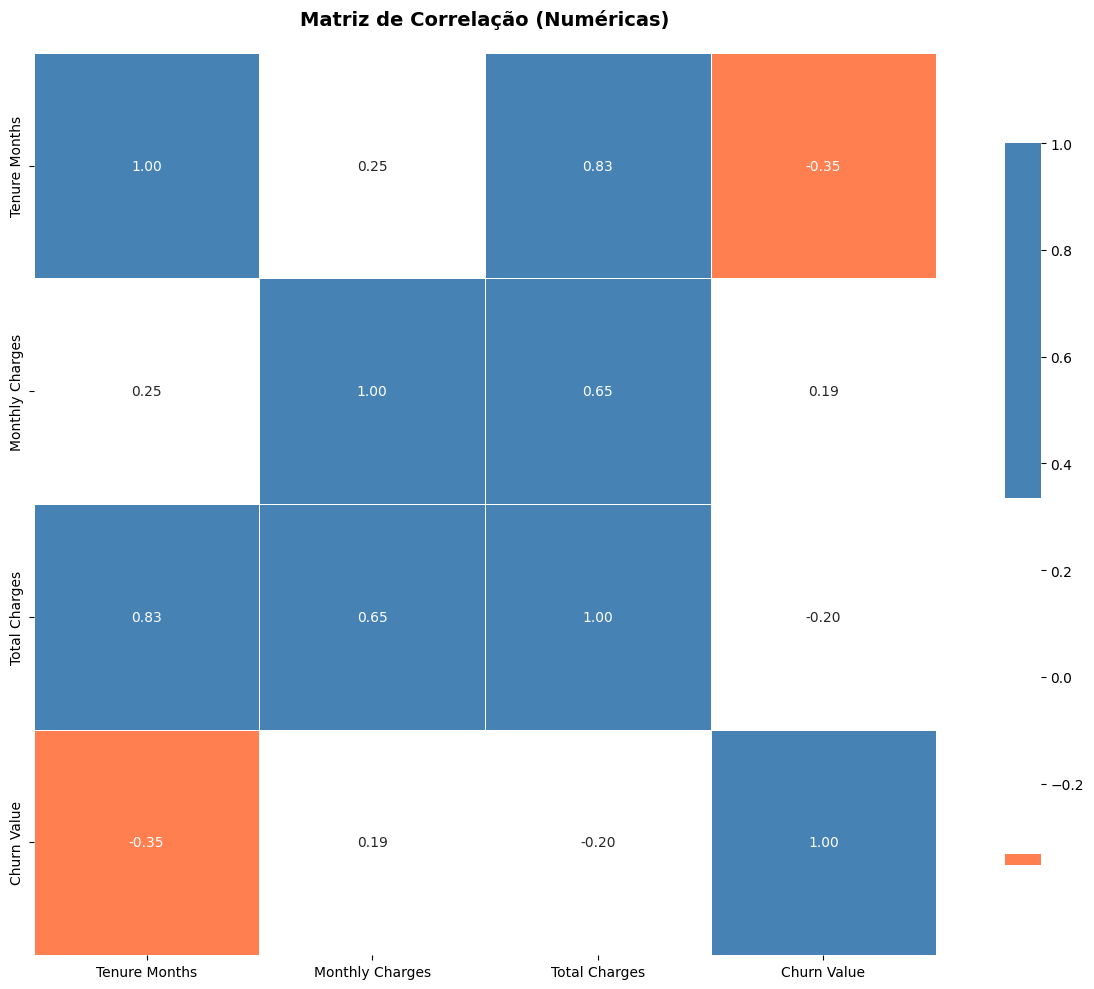

22:46:32 | INFO | Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\multivariada\correlacao\correlation_matrix_numeric.png
22:46:32 | INFO | === CORRELAÇÕES COM TARGET ===
22:46:32 | INFO | Monthly Charges | corr_target=0.1934
22:46:32 | INFO | Total Charges | corr_target=-0.1995
22:46:32 | INFO | Tenure Months | corr_target=-0.3522
22:46:32 | INFO | === ANÁLISE DE MULTICOLINEARIDADE (CORR) ===
22:46:32 | WARNING | Foram encontrados 1 pares com correlação >= 0.70
22:46:32 | WARNING | HIGH_CORR | Tenure Months vs Total Charges | corr=0.8259
22:46:32 | INFO | === ANÁLISE DE VIF (MULTICOLINEARIDADE AVANÇADA) ===
22:46:32 | INFO | Feature: Total Charges        | VIF: 8.0792
22:46:32 | INFO | Feature: Tenure Months        | VIF: 6.3324
22:46:32 | INFO | Feature: Monthly Charges      | VIF: 3.3611
22:46:32 | INFO | Análise de correlação e multicolinearidade finalizada.


In [150]:
logger.info("Iniciando análise de correlação e multicolinearidade.")


# ── Seleção de variáveis numéricas ─────────────────────────────────────
df_num = df.select_dtypes(include=[np.number]).copy()

if TARGET not in df_num.columns:
    logger.warning("TARGET '%s' não está entre variáveis numéricas.", TARGET)

# ── Matriz de correlação ───────────────────────────────────────────────
corr_matrix = df_num.corr()

# ── Plot heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        [CORES["destaque"], "white", CORES["secundaria"]], as_cmap=True
    ),
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Matriz de Correlação (Numéricas)", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()

output_path = REPORT_FIGURES_CORRELACAO / "correlation_matrix_numeric.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close()

logger.info("Artefato salvo: %s", output_path)

# ── Correlação com TARGET ──────────────────────────────────────────────
if TARGET in corr_matrix.columns:
    target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

    logger.info("=== CORRELAÇÕES COM TARGET ===")

    for feature, value in target_corr.items():
        logger.info("%s | corr_target=%.4f", feature, value)

else:
    logger.warning("TARGET '%s' não encontrado na matriz de correlação.", TARGET)

# ── Multicolinearidade (correlação entre features) ─────────────────────
logger.info("=== ANÁLISE DE MULTICOLINEARIDADE (CORR) ===")

threshold = 0.7
high_corr_pairs = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]

        if f1 == TARGET or f2 == TARGET:
            continue

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:
            high_corr_pairs.append(
                {"feature_1": f1, "feature_2": f2, "correlation": round(corr_val, 4)}
            )

# ── Log resultados ─────────────────────────────────────────────────────
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        by="correlation", ascending=False
    )

    logger.warning(
        "Foram encontrados %d pares com correlação >= %.2f",
        len(high_corr_df),
        threshold,
    )

    for _, row in high_corr_df.iterrows():
        logger.warning(
            "%s | %s vs %s | corr=%.4f",
            "HIGH_CORR",
            row["feature_1"],
            row["feature_2"],
            row["correlation"],
        )
else:
    logger.info("Nenhuma correlação forte detectada entre features.")

# ── VIF (Variance Inflation Factor) ────────────────────────────────────
logger.info("=== ANÁLISE DE VIF (MULTICOLINEARIDADE AVANÇADA) ===")

# remover target
features_vif = df_num.drop(columns=[TARGET], errors="ignore").dropna()

vif_data = []

for i in range(features_vif.shape[1]):
    vif = variance_inflation_factor(features_vif.values, i)
    feature_name = features_vif.columns[i]

    vif_data.append({"feature": feature_name, "vif": round(vif, 4)})

vif_df = pd.DataFrame(vif_data).sort_values(by="vif", ascending=False)

# ── Log VIF ────────────────────────────────────────────────────────────
for _, row in vif_df.iterrows():
    logger.info("Feature: %-20s | VIF: %.4f", row["feature"], row["vif"])

logger.info("Análise de correlação e multicolinearidade finalizada.")